In [1]:
# ============================================================
# LOAD PREPROCESSED DATA
# ============================================================

import pandas as pd
import numpy as np
from collections import Counter

# Load preprocessed train and test data
X_train_final = pd.read_parquet('../data/cleaned/X_train_preprocessed.parquet')
X_test_final = pd.read_parquet('../data/cleaned/X_test_preprocessed.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
y_test = pd.read_parquet('../data/cleaned/y_test.parquet').squeeze()

print("="*70)
print("DATA LOADED SUCCESSFULLY")
print("="*70)
print(f"✓ X_train shape: {X_train_final.shape}")
print(f"✓ X_test shape: {X_test_final.shape}")
print(f"✓ y_train shape: {y_train.shape}")
print(f"✓ y_test shape: {y_test.shape}")

DATA LOADED SUCCESSFULLY
✓ X_train shape: (103986, 40)
✓ X_test shape: (25997, 40)
✓ y_train shape: (103986,)
✓ y_test shape: (25997,)


In [2]:
# ============================================================
# TARGET VARIABLE ANALYSIS
# ============================================================

print("\n" + "="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)

train_counts = Counter(y_train)
test_counts = Counter(y_test)

print(f"\nTrain target distribution:")
for label, count in sorted(train_counts.items()):
    pct = (count / len(y_train)) * 100
    print(f"  Class {label}: {count:,} ({pct:.2f}%)")

print(f"\nTest target distribution:")
for label, count in sorted(test_counts.items()):
    pct = (count / len(y_test)) * 100
    print(f"  Class {label}: {count:,} ({pct:.2f}%)")

# Calculate imbalance ratio
minority_class = min(train_counts, key=train_counts.get)
majority_class = max(train_counts, key=train_counts.get)
imbalance_ratio = train_counts[majority_class] / train_counts[minority_class]

print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"Minority class ({minority_class}): {train_counts[minority_class]:,} samples")
print(f"Majority class ({majority_class}): {train_counts[majority_class]:,} samples")


TARGET VARIABLE ANALYSIS

Train target distribution:
  Class 0: 17,178 (16.52%)
  Class 1: 86,808 (83.48%)

Test target distribution:
  Class 0: 4,295 (16.52%)
  Class 1: 21,702 (83.48%)

Imbalance ratio: 5.05:1
Minority class (0): 17,178 samples
Majority class (1): 86,808 samples


In [8]:
X_train_final.dtypes


provider_code             category
year                      category
age_band                  category
gender                     float64
t0_assisted                float64
t0_assisted_by               uint8
t0_symptom_period          float64
t0_previous_surgery        float64
t0_living_arrangements    category
t0_disability              float64
heart_disease                int64
high_bp                      int64
stroke                       int64
circulation                  int64
lung_disease                 int64
diabetes                     int64
kidney_disease               int64
nervous_system               int64
liver_disease                int64
cancer                       int64
depression                   int64
arthritis                    int64
t0_mobility                float64
t0_self_care               float64
t0_activity                float64
t0_discomfort              float64
t0_anxiety                 float64
oks_t0_pain                  uint8
oks_t0_night_pain   

## Extra Feature Engineering

### Academic Hospitals vs Non Academic hospitals

Since university hospitals can deal with worse/more advanced cases, the provider codes are transformed based on their status

In [11]:
# Read data from proms_providers_academic_categories.xlsx

proms_academic_df = pd.read_excel('../data/supporting/proms_providers_academic_categories.xlsx')

proms_academic_df.head()

# Transform academisch/niet academisch to 1/0
proms_academic_df['University Hospital'] = proms_academic_df['category'].map({'academisch': 1, 'niet-academisch': 0})
proms_academic_df.head(50)

# Merge with X_train_final and X_test_final
X_train_final = X_train_final.merge(proms_academic_df[['provider_code', 'University Hospital']], on='provider_code', how='left')
X_test_final = X_test_final.merge(proms_academic_df[['provider_code', 'University Hospital']], on='provider_code', how='left')

X_train_final['University Hospital'].value_counts()
X_test_final['University Hospital'].value_counts()

0    20353
1     5644
Name: University Hospital, dtype: int64

In [13]:
X_train_final.head()

,provider_code,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,...,oks_t0_walking,oks_t0_standing,oks_t0_limping,oks_t0_kneeling,oks_t0_work,oks_t0_confidence,oks_t0_shopping,oks_t0_stairs,oks_t0_score,University Hospital
0,RTH,2017/18,4,0.0,0.0,0,4.0,0.0,1.0,0.0,...,1,2,3,1,3,0,4,2,26.0,1
1,RN5,2017/18,5,1.0,0.0,0,2.0,0.0,2.0,1.0,...,2,3,1,0,0,0,2,1,19.0,0
2,RQ8,2017/18,4,1.0,0.0,0,2.0,0.0,1.0,1.0,...,2,3,0,2,2,3,3,2,24.0,0
3,RBT,2016/17,5,0.0,0.0,0,2.0,0.0,1.0,0.0,...,2,1,1,1,1,1,1,1,12.0,0
4,NVC23,2016/17,3,1.0,0.0,0,2.0,0.0,1.0,0.0,...,2,3,2,2,2,2,2,2,26.0,0


Analyze the distribution between number of surgeries (size of hospitals) and scores they have achieved and document whether there is a pattern

In [41]:
# Extract top 10 most common provider codes with their value counts and how much they appear in the training set (% wise of total)
top_50_providers = X_train_final['provider_code'].value_counts().nsmallest(50).index.tolist()

for provider in top_50_providers:
    count = X_train_final['provider_code'].value_counts()[provider]
    pct = (count / len(X_train_final)) * 100
    print(f"Provider Code: {provider}, Count: {count}, Percentage of Training Set: {pct:.2f}%")
# ============================================================

Provider Code: RJ7, Count: 3, Percentage of Training Set: 0.00%
Provider Code: NT343, Count: 8, Percentage of Training Set: 0.01%
Provider Code: NYW01, Count: 9, Percentage of Training Set: 0.01%
Provider Code: NT30A, Count: 9, Percentage of Training Set: 0.01%
Provider Code: NT310, Count: 10, Percentage of Training Set: 0.01%
Provider Code: NFH01, Count: 10, Percentage of Training Set: 0.01%
Provider Code: NT455, Count: 10, Percentage of Training Set: 0.01%
Provider Code: NVC0R, Count: 15, Percentage of Training Set: 0.01%
Provider Code: NT241, Count: 17, Percentage of Training Set: 0.02%
Provider Code: NT416, Count: 17, Percentage of Training Set: 0.02%
Provider Code: NT315, Count: 17, Percentage of Training Set: 0.02%
Provider Code: NQM01, Count: 18, Percentage of Training Set: 0.02%
Provider Code: NT308, Count: 19, Percentage of Training Set: 0.02%
Provider Code: NT211, Count: 22, Percentage of Training Set: 0.02%
Provider Code: NT205, Count: 22, Percentage of Training Set: 0.02%
P

In [17]:
# ============================================================
# ONE-HOT ENCODE CATEGORICAL VARIABLES
# ============================================================

import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import joblib

# Define categorical columns to encode
categorical_columns = [
    'year', 'age_band', 
    't0_living_arrangements'
]

print("="*70)
print("ONE-HOT ENCODING CATEGORICAL VARIABLES")
print("="*70)

# Check which categorical columns exist in the data
existing_categorical = [col for col in categorical_columns if col in X_train_final.columns]
print(f"\nCategorical columns found: {existing_categorical}")

# ============================================================
# FIT ONE-HOT ENCODER ON TRAINING DATA
# ============================================================

# Initialize encoder
encoder = OneHotEncoder(
    drop='first',           # Drop first category to avoid multicollinearity
    sparse_output=False,    # Return dense array (easier to work with)
    handle_unknown='ignore' # Ignore unknown categories in test set
)

# Fit on training data
print(f"\n✓ Fitting encoder on training data...")
encoder.fit(X_train_final[existing_categorical])

# Get feature names for encoded columns
encoded_feature_names = encoder.get_feature_names_out(existing_categorical)
print(f"✓ Encoder fitted - will create {len(encoded_feature_names)} one-hot encoded features")

# ============================================================
# TRANSFORM TRAINING DATA
# ============================================================

print(f"\n✓ Transforming training data...")

# Transform categorical columns
X_train_encoded = encoder.transform(X_train_final[existing_categorical])

# Create DataFrame with encoded features
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train_final.index
)

# Drop original categorical columns and add encoded ones
X_train_numerical = X_train_final.drop(columns=existing_categorical)
X_train_final_encoded = pd.concat([X_train_numerical, X_train_encoded_df], axis=1)

print(f"✓ Training data shape before encoding: {X_train_final.shape}")
print(f"✓ Training data shape after encoding: {X_train_final_encoded.shape}")

# ============================================================
# TRANSFORM TEST DATA
# ============================================================

print(f"\n✓ Transforming test data...")

# Transform categorical columns (using fitted encoder)
X_test_encoded = encoder.transform(X_test_final[existing_categorical])

# Create DataFrame with encoded features
X_test_encoded_df = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test_final.index
)

# Drop original categorical columns and add encoded ones
X_test_numerical = X_test_final.drop(columns=existing_categorical)
X_test_final_encoded = pd.concat([X_test_numerical, X_test_encoded_df], axis=1)

print(f"✓ Test data shape before encoding: {X_test_final.shape}")
print(f"✓ Test data shape after encoding: {X_test_final_encoded.shape}")

# ============================================================
# VERIFICATION
# ============================================================

print("\n" + "="*70)
print("ENCODING VERIFICATION")
print("="*70)

print(f"\n✓ X_train_final_encoded shape: {X_train_final_encoded.shape}")
print(f"✓ X_test_final_encoded shape: {X_test_final_encoded.shape}")
print(f"✓ Both datasets have same number of features: {X_train_final_encoded.shape[1] == X_test_final_encoded.shape[1]}")

# Check for missing values
print(f"\n✓ Missing values in X_train_final_encoded: {X_train_final_encoded.isna().sum().sum()}")
print(f"✓ Missing values in X_test_final_encoded: {X_test_final_encoded.isna().sum().sum()}")

# Show sample of new columns
print("\n" + "="*70)
print("SAMPLE OF ONE-HOT ENCODED FEATURES")
print("="*70)

# Show first few encoded feature names for each original categorical variable
for original_col in existing_categorical:
    encoded_cols = [col for col in encoded_feature_names if col.startswith(original_col)]
    print(f"\n{original_col} → {len(encoded_cols)} one-hot features:")
    print(f"  Sample: {encoded_cols[:5]}")

# Show data sample
print("\n" + "="*70)
print("DATA PREVIEW (First 5 rows, first 10 columns)")
print("="*70)
print(X_train_final_encoded.iloc[:5, :10])

# ============================================================
# SAVE ENCODED DATA (Optional)
# ============================================================

print("\n" + "="*70)
print("SAVING ENCODED DATA")
print("="*70)

# Save encoded datasets
X_train_final_encoded.to_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet', index=False)
X_test_final_encoded.to_parquet('../data/cleaned/X_test_encoded_wo_provider.parquet', index=False)

# Save encoder for future use
joblib.dump(encoder, '../data/cleaned/onehot_encoder_wo_provider.pkl')

print("✓ X_train_final_encoded saved to '../data/cleaned/X_train_encoded.parquet'")
print("✓ X_test_final_encoded saved to '../data/cleaned/X_test_encoded.parquet'")
print("✓ OneHotEncoder saved to '../data/cleaned/onehot_encoder.pkl'")

# ============================================================
# FEATURE COUNTS BY TYPE
# ============================================================

print("\n" + "="*70)
print("FEATURE BREAKDOWN")
print("="*70)

# Count features by original type
numerical_features = X_train_numerical.columns.tolist()
encoded_features = encoded_feature_names.tolist()

print(f"\nNumerical features (unchanged): {len(numerical_features)}")
print(f"One-hot encoded features (new): {len(encoded_features)}")
print(f"Total features: {len(X_train_final_encoded.columns)}")

print("\n" + "="*70)
print("✓ ONE-HOT ENCODING COMPLETE - DATA READY FOR MODELING")
print("="*70)

# ============================================================
# How to load encoder and apply to new data later:
# ============================================================
"""
# Load the fitted encoder
encoder = joblib.load('../data/processed/onehot_encoder.pkl')

# Apply to new data
X_new_encoded = encoder.transform(X_new[existing_categorical])
X_new_encoded_df = pd.DataFrame(
    X_new_encoded,
    columns=encoder.get_feature_names_out(existing_categorical),
    index=X_new.index
)
X_new_numerical = X_new.drop(columns=existing_categorical)
X_new_final = pd.concat([X_new_numerical, X_new_encoded_df], axis=1)
"""

ONE-HOT ENCODING CATEGORICAL VARIABLES

Categorical columns found: ['year', 'age_band', 't0_living_arrangements']

✓ Fitting encoder on training data...
✓ Encoder fitted - will create 7 one-hot encoded features

✓ Transforming training data...
✓ Training data shape before encoding: (103986, 41)
✓ Training data shape after encoding: (103986, 45)

✓ Transforming test data...
✓ Test data shape before encoding: (25997, 41)
✓ Test data shape after encoding: (25997, 45)

ENCODING VERIFICATION

✓ X_train_final_encoded shape: (103986, 45)
✓ X_test_final_encoded shape: (25997, 45)
✓ Both datasets have same number of features: True

✓ Missing values in X_train_final_encoded: 0
✓ Missing values in X_test_final_encoded: 0

SAMPLE OF ONE-HOT ENCODED FEATURES

year → 2 one-hot features:
  Sample: ['year_2017/18', 'year_2018/19']

age_band → 3 one-hot features:
  Sample: ['age_band_3', 'age_band_4', 'age_band_5']

t0_living_arrangements → 2 one-hot features:
  Sample: ['t0_living_arrangements_2.0', '

"\n# Load the fitted encoder\nencoder = joblib.load('../data/processed/onehot_encoder.pkl')\n\n# Apply to new data\nX_new_encoded = encoder.transform(X_new[existing_categorical])\nX_new_encoded_df = pd.DataFrame(\n    X_new_encoded,\n    columns=encoder.get_feature_names_out(existing_categorical),\n    index=X_new.index\n)\nX_new_numerical = X_new.drop(columns=existing_categorical)\nX_new_final = pd.concat([X_new_numerical, X_new_encoded_df], axis=1)\n"

📊 Modeling Guide – Where to Start

🎯 1. Problem Summary
- Task: Binary classification
- Target: oks_target_variable (whether patient improvement > 7 points)
- Class Imbalance: ~5:1 ratio (majority class dominates)
- Data: Fully preprocessed, no missing values, ready for modeling

🔧 2. Handling Class Imbalance
- You have several options:
✅ Option A: Class Weights (Recommended first approach)

- Use class_weight='balanced' in your classifier
- No need to modify data
- Works with: LogisticRegression, RandomForest, XGBoost, etc.

✅ Option B: Resampling (SMOTE)

- Apply SMOTE only to training data inside cross-validation
- Use imblearn.pipeline.Pipeline to prevent data leakage
- Best for smaller datasets

✅ Option C: Threshold Tuning

- Train normally, then adjust decision threshold
- Optimize for your preferred metric (F1, recall, precision)


📈 3. Evaluation Metrics
Given class imbalance, DO NOT rely solely on accuracy. Focus on:
Primary Metrics

- F1-Score (balance between precision and recall)
- ROC-AUC (overall discrimination ability)
- Precision-Recall AUC (better for imbalanced data)

Secondary Metrics

- Recall (if you want to catch all positive cases)
- Precision (if false positives are costly)
- Confusion Matrix (understand errors)


🧪 4. Model Selection Strategy
Baseline Models (Start here)

- Logistic Regression (class_weight='balanced')
- Random Forest (class_weight='balanced')
- Dummy Classifier (minimum performance)

Advanced Models (After baseline)

- XGBoost or LightGBM (handle categorical features well)
- CatBoost (native categorical support)
- Ensemble methods (stacking, voting)


🔄 5. Cross-Validation Strategy

- Use StratifiedKFold (5–10 folds)
- Maintains class distribution in each fold
- Report mean ± std of metrics

Important:

- If using SMOTE, apply it inside each CV fold
- Use imblearn.pipeline.Pipeline to prevent leakage


🎛️ 6. Hyperparameter Tuning
- Step 1: Train baseline models with default parameters
- Step 2: Use GridSearchCV or RandomizedSearchCV
- Step 3: Focus on models that performed best in baseline
Key Parameters to Tune
Random Forest
- Plain Textn_estimators: [100, 200, 500]max_depth: [10, 20, None]min_samples_split: [2, 5, 10]class_weight: ['balanced']Show more lines
XGBoost
- Plain Textn_estimators: [100, 200, 500]learning_rate: [0.01, 0.1, 0.3]max_depth: [3, 5, 7]scale_pos_weight: [calculated from class ratio]Show more lines

📊 7. Feature Engineering (Optional)

Feature Interactions:
- Example: age_band * heart_disease
Feature Selection:
- Use feature importance from tree-based models
- Try Recursive Feature Elimination (RFE)
Categorical Encoding:

- One-Hot Encoding for low-cardinality features
- Target Encoding for high-cardinality features (e.g., provider_code)

⚠️ 8. Important Reminders
- ✅ Use stratified cross-validation
- ✅ Focus on F1/ROC-AUC, not just accuracy
- ✅ Handle class imbalance (class weights or SMOTE)
- ✅ Evaluate on test set ONLY ONCE at the end
- ✅ Save your best model with joblib
- ❌ Touch the test set during model development
- ❌ Use SMOTE before train-test split
- ❌ Rely on accuracy alone for imbalanced data
- ❌ Forget to set random_state for reproducibility
- ❌ Oversample test data

# Encoded data

In [28]:
# Load encoded data

X_train_final_encoded = pd.read_parquet('../data/cleaned/X_train_encoded_wo_provider.parquet')
y_train = pd.read_parquet('../data/cleaned/y_train.parquet').squeeze()
print("✓ Encoded data loaded successfully")

✓ Encoded data loaded successfully


In [29]:
# Swap class labels: 0 becomes 1, and 1 becomes 0
y_train = 1 - y_train

display(y_train.value_counts())

oks_target_variable
0    86808
1    17178
Name: count, dtype: int64

In [30]:
X_train_final_encoded.head(5)

,provider_code,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,...,oks_t0_stairs,oks_t0_score,University Hospital,year_2017/18,year_2018/19,age_band_3,age_band_4,age_band_5,t0_living_arrangements_2.0,t0_living_arrangements_4.0
0,RTH,0.0,0.0,0,4.0,0.0,0.0,0,1,0,...,2,26.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,RN5,1.0,0.0,0,2.0,0.0,1.0,0,1,0,...,1,19.0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,RQ8,1.0,0.0,0,2.0,0.0,1.0,0,1,0,...,2,24.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,RBT,0.0,0.0,0,2.0,0.0,0.0,1,1,0,...,1,12.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,NVC23,1.0,0.0,0,2.0,0.0,0.0,0,1,0,...,2,26.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [31]:
# Drop provider_code
X_train_final_encoded = X_train_final_encoded.drop(columns=['provider_code'])
X_train_final_encoded.head(5)

,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_disability,heart_disease,high_bp,stroke,circulation,...,oks_t0_stairs,oks_t0_score,University Hospital,year_2017/18,year_2018/19,age_band_3,age_band_4,age_band_5,t0_living_arrangements_2.0,t0_living_arrangements_4.0
0,0.0,0.0,0,4.0,0.0,0.0,0,1,0,0,...,2,26.0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.0,0.0,0,2.0,0.0,1.0,0,1,0,0,...,1,19.0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0,2.0,0.0,1.0,0,1,0,0,...,2,24.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0,2.0,0.0,0.0,1,1,0,0,...,1,12.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0,2.0,0.0,0.0,0,1,0,0,...,2,26.0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [32]:
# ============================================================================
# LOGISTIC REGRESSION WITH CLASS WEIGHTS AND 5-FOLD CROSS-VALIDATION
# ============================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report,
    make_scorer
)
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("LOGISTIC REGRESSION WITH CLASS WEIGHTS - 5-FOLD CROSS-VALIDATION")
print("="*80)

# ============================================================================
# 1. CALCULATE CLASS WEIGHTS
# ============================================================================

print("\n📊 STEP 1: CALCULATING CLASS WEIGHTS")
print("-" * 80)

# Get class distribution
unique_classes = np.unique(y_train)
class_counts = np.bincount(y_train)

print(f"Class distribution:")
for cls in unique_classes:
    count = class_counts[cls]
    pct = (count / len(y_train)) * 100
    print(f"  Class {cls}: {count:,} ({pct:.2f}%)")

# Calculate class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

# Create class weight dictionary
class_weight_dict = {cls: weight for cls, weight in zip(unique_classes, class_weights)}

print(f"\nCalculated class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

print(f"\nWeight ratio: {class_weight_dict[0] / class_weight_dict[1]:.2f}:1")
print("✓ Class weights will penalize errors on minority class more heavily")

LOGISTIC REGRESSION WITH CLASS WEIGHTS - 5-FOLD CROSS-VALIDATION

📊 STEP 1: CALCULATING CLASS WEIGHTS
--------------------------------------------------------------------------------
Class distribution:
  Class 0: 86,808 (83.48%)
  Class 1: 17,178 (16.52%)

Calculated class weights:
  Class 0: 0.5989
  Class 1: 3.0267

Weight ratio: 0.20:1
✓ Class weights will penalize errors on minority class more heavily


In [33]:
# ============================================================================
# 2. INITIALIZE LOGISTIC REGRESSION MODEL
# ============================================================================

print("\n🔧 STEP 2: INITIALIZING LOGISTIC REGRESSION MODEL")
print("-" * 80)

# Create logistic regression model with class weights
lr_model = LogisticRegression(
    class_weight='balanced',  # Automatically handle class imbalance
    max_iter=1000,           # Increase iterations for convergence
    random_state=42,         # For reproducibility
    solver='lbfgs',          # Good for small to medium datasets
    n_jobs=-1                # Use all CPU cores
)

print("Model parameters:")
print(f"  ✓ Class weight: balanced")
print(f"  ✓ Max iterations: 1000")
print(f"  ✓ Solver: lbfgs")
print(f"  ✓ Random state: 42")


🔧 STEP 2: INITIALIZING LOGISTIC REGRESSION MODEL
--------------------------------------------------------------------------------
Model parameters:
  ✓ Class weight: balanced
  ✓ Max iterations: 1000
  ✓ Solver: lbfgs
  ✓ Random state: 42


In [34]:

# ============================================================================
# 3. DEFINE CROSS-VALIDATION STRATEGY
# ============================================================================

print("\n🔄 STEP 3: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION")
print("-" * 80)

# Use StratifiedKFold to maintain class distribution in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(f"  ✓ Number of folds: 5")
print(f"  ✓ Stratified: Yes (maintains class distribution)")
print(f"  ✓ Shuffle: Yes")
print(f"  ✓ Random state: 42")

# Verify class distribution in each fold
print("\nClass distribution verification across folds:")
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_train_final_encoded, y_train), 1):
    y_fold = y_train.iloc[val_idx]
    class_0_pct = (y_fold == 0).sum() / len(y_fold) * 100
    class_1_pct = (y_fold == 1).sum() / len(y_fold) * 100
    print(f"  Fold {fold_idx}: Class 0: {class_0_pct:.2f}% | Class 1: {class_1_pct:.2f}%")


🔄 STEP 3: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION
--------------------------------------------------------------------------------
Cross-validation strategy:
  ✓ Number of folds: 5
  ✓ Stratified: Yes (maintains class distribution)
  ✓ Shuffle: Yes
  ✓ Random state: 42

Class distribution verification across folds:
  Fold 1: Class 0: 83.48% | Class 1: 16.52%
  Fold 2: Class 0: 83.48% | Class 1: 16.52%
  Fold 3: Class 0: 83.48% | Class 1: 16.52%
  Fold 4: Class 0: 83.48% | Class 1: 16.52%
  Fold 5: Class 0: 83.48% | Class 1: 16.52%


In [35]:
# ============================================================================
# 4. DEFINE SCORING METRICS
# ============================================================================

print("\n📈 STEP 4: DEFINING EVALUATION METRICS")
print("-" * 80)

# Define multiple scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision_recall_auc': 'average_precision'  # PR-AUC, better for imbalanced data
}

print("Metrics to evaluate:")
for metric_name in scoring.keys():
    print(f"  ✓ {metric_name}")


📈 STEP 4: DEFINING EVALUATION METRICS
--------------------------------------------------------------------------------
Metrics to evaluate:
  ✓ accuracy
  ✓ precision
  ✓ recall
  ✓ f1
  ✓ roc_auc
  ✓ precision_recall_auc


In [36]:

# ============================================================================
# 5. PERFORM CROSS-VALIDATION
# ============================================================================

print("\n⚙️ STEP 5: RUNNING 5-FOLD CROSS-VALIDATION")
print("-" * 80)
print("This may take a few moments...\n")

# Perform cross-validation
cv_results = cross_validate(
    estimator=lr_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

print("✓ Cross-validation complete!")


⚙️ STEP 5: RUNNING 5-FOLD CROSS-VALIDATION
--------------------------------------------------------------------------------
This may take a few moments...

✓ Cross-validation complete!


In [37]:
# ============================================================================
# 6. DISPLAY RESULTS
# ============================================================================

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS (5-FOLD)")
print("="*80)

# Create results DataFrame
results_df = pd.DataFrame({
    'Metric': [],
    'Train Mean': [],
    'Train Std': [],
    'Val Mean': [],
    'Val Std': []
})

for metric_name in scoring.keys():
    train_scores = cv_results[f'train_{metric_name}']
    val_scores = cv_results[f'test_{metric_name}']
    
    results_df = pd.concat([results_df, pd.DataFrame({
        'Metric': [metric_name.upper()],
        'Train Mean': [train_scores.mean()],
        'Train Std': [train_scores.std()],
        'Val Mean': [val_scores.mean()],
        'Val Std': [val_scores.std()]
    })], ignore_index=True)

# Display results table
print("\n" + results_df.to_string(index=False))


CROSS-VALIDATION RESULTS (5-FOLD)

              Metric  Train Mean  Train Std  Val Mean  Val Std
            ACCURACY    0.671261   0.001410  0.670408 0.002188
           PRECISION    0.278078   0.001307  0.277151 0.003640
              RECALL    0.620241   0.001542  0.618931 0.012465
                  F1    0.383995   0.001504  0.382853 0.005761
             ROC_AUC    0.708326   0.001705  0.706974 0.006714
PRECISION_RECALL_AUC    0.369971   0.001921  0.368814 0.008355


In [38]:
# ============================================================================
# 7. DETAILED METRIC ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("DETAILED METRIC ANALYSIS")
print("="*80)

for metric_name in scoring.keys():
    train_scores = cv_results[f'train_{metric_name}']
    val_scores = cv_results[f'test_{metric_name}']
    
    print(f"\n{metric_name.upper()}:")
    print(f"  Training:   {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Validation: {val_scores.mean():.4f} ± {val_scores.std():.4f}")
    print(f"  Fold scores: {[f'{score:.4f}' for score in val_scores]}")
    
    # Check for overfitting
    gap = train_scores.mean() - val_scores.mean()
    if gap > 0.05:
        print(f"  ⚠️ Warning: Train-val gap = {gap:.4f} (possible overfitting)")
    else:
        print(f"  ✓ Train-val gap = {gap:.4f} (good)")


DETAILED METRIC ANALYSIS

ACCURACY:
  Training:   0.6713 ± 0.0014
  Validation: 0.6704 ± 0.0022
  Fold scores: ['0.6723', '0.6706', '0.6731', '0.6673', '0.6687']
  ✓ Train-val gap = 0.0009 (good)

PRECISION:
  Training:   0.2781 ± 0.0013
  Validation: 0.2772 ± 0.0036
  Fold scores: ['0.2810', '0.2735', '0.2814', '0.2726', '0.2772']
  ✓ Train-val gap = 0.0009 (good)

RECALL:
  Training:   0.6202 ± 0.0015
  Validation: 0.6189 ± 0.0125
  Fold scores: ['0.6310', '0.6003', '0.6300', '0.6080', '0.6254']
  ✓ Train-val gap = 0.0013 (good)

F1:
  Training:   0.3840 ± 0.0015
  Validation: 0.3829 ± 0.0058
  Fold scores: ['0.3888', '0.3758', '0.3890', '0.3765', '0.3842']
  ✓ Train-val gap = 0.0011 (good)

ROC_AUC:
  Training:   0.7083 ± 0.0017
  Validation: 0.7070 ± 0.0067
  Fold scores: ['0.7126', '0.6957', '0.7148', '0.7047', '0.7072']
  ✓ Train-val gap = 0.0014 (good)

PRECISION_RECALL_AUC:
  Training:   0.3700 ± 0.0019
  Validation: 0.3688 ± 0.0084
  Fold scores: ['0.3759', '0.3588', '0.3805'

In [39]:
# ============================================================================
# 8. KEY INSIGHTS
# ============================================================================

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)

val_f1 = cv_results['test_f1'].mean()
val_roc_auc = cv_results['test_roc_auc'].mean()
val_precision = cv_results['test_precision'].mean()
val_recall = cv_results['test_recall'].mean()
val_accuracy = cv_results['test_accuracy'].mean()

print(f"\n✓ Primary Metrics:")
print(f"  • F1-Score: {val_f1:.4f} (balance between precision and recall)")
print(f"  • ROC-AUC: {val_roc_auc:.4f} (overall discrimination ability)")

print(f"\n✓ Performance Breakdown:")
print(f"  • Accuracy: {val_accuracy:.4f}")
print(f"  • Precision: {val_precision:.4f} (how many predicted positives are correct)")
print(f"  • Recall: {val_recall:.4f} (how many actual positives we catch)")

print(f"\n💡 Interpretation:")
if val_f1 > 0.7:
    print(f"  ✓ Excellent F1-score ({val_f1:.4f}) - model performs well")
elif val_f1 > 0.5:
    print(f"  ✓ Good F1-score ({val_f1:.4f}) - model shows promise")
else:
    print(f"  ⚠️ Low F1-score ({val_f1:.4f}) - model may need improvement")

if val_roc_auc > 0.8:
    print(f"  ✓ Excellent ROC-AUC ({val_roc_auc:.4f}) - strong discriminative ability")
elif val_roc_auc > 0.7:
    print(f"  ✓ Good ROC-AUC ({val_roc_auc:.4f}) - decent discriminative ability")
else:
    print(f"  ⚠️ Low ROC-AUC ({val_roc_auc:.4f}) - weak discriminative ability")

# Check class weight effectiveness
if val_recall > 0.6:
    print(f"  ✓ Class weights working well (recall = {val_recall:.4f})")
else:
    print(f"  ⚠️ Consider adjusting class weights (recall = {val_recall:.4f})")

print("\n" + "="*80)
print("✓ CROSS-VALIDATION COMPLETE")
print("="*80)


KEY INSIGHTS

✓ Primary Metrics:
  • F1-Score: 0.3829 (balance between precision and recall)
  • ROC-AUC: 0.7070 (overall discrimination ability)

✓ Performance Breakdown:
  • Accuracy: 0.6704
  • Precision: 0.2772 (how many predicted positives are correct)
  • Recall: 0.6189 (how many actual positives we catch)

💡 Interpretation:
  ⚠️ Low F1-score (0.3829) - model may need improvement
  ✓ Good ROC-AUC (0.7070) - decent discriminative ability
  ✓ Class weights working well (recall = 0.6189)

✓ CROSS-VALIDATION COMPLETE


C:\Users\asaras\AppData\Local\Temp\ipykernel_41920\2140206417.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x='Metric', y='Score', ax=ax3, palette='Set2')
C:\Users\asaras\AppData\Local\Temp\ipykernel_41920\2140206417.py:106: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
C:\Users\asaras\AppData\Local\Temp\ipykernel_41920\2140206417.py:122: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(metrics_list, rotation=45, ha='right')


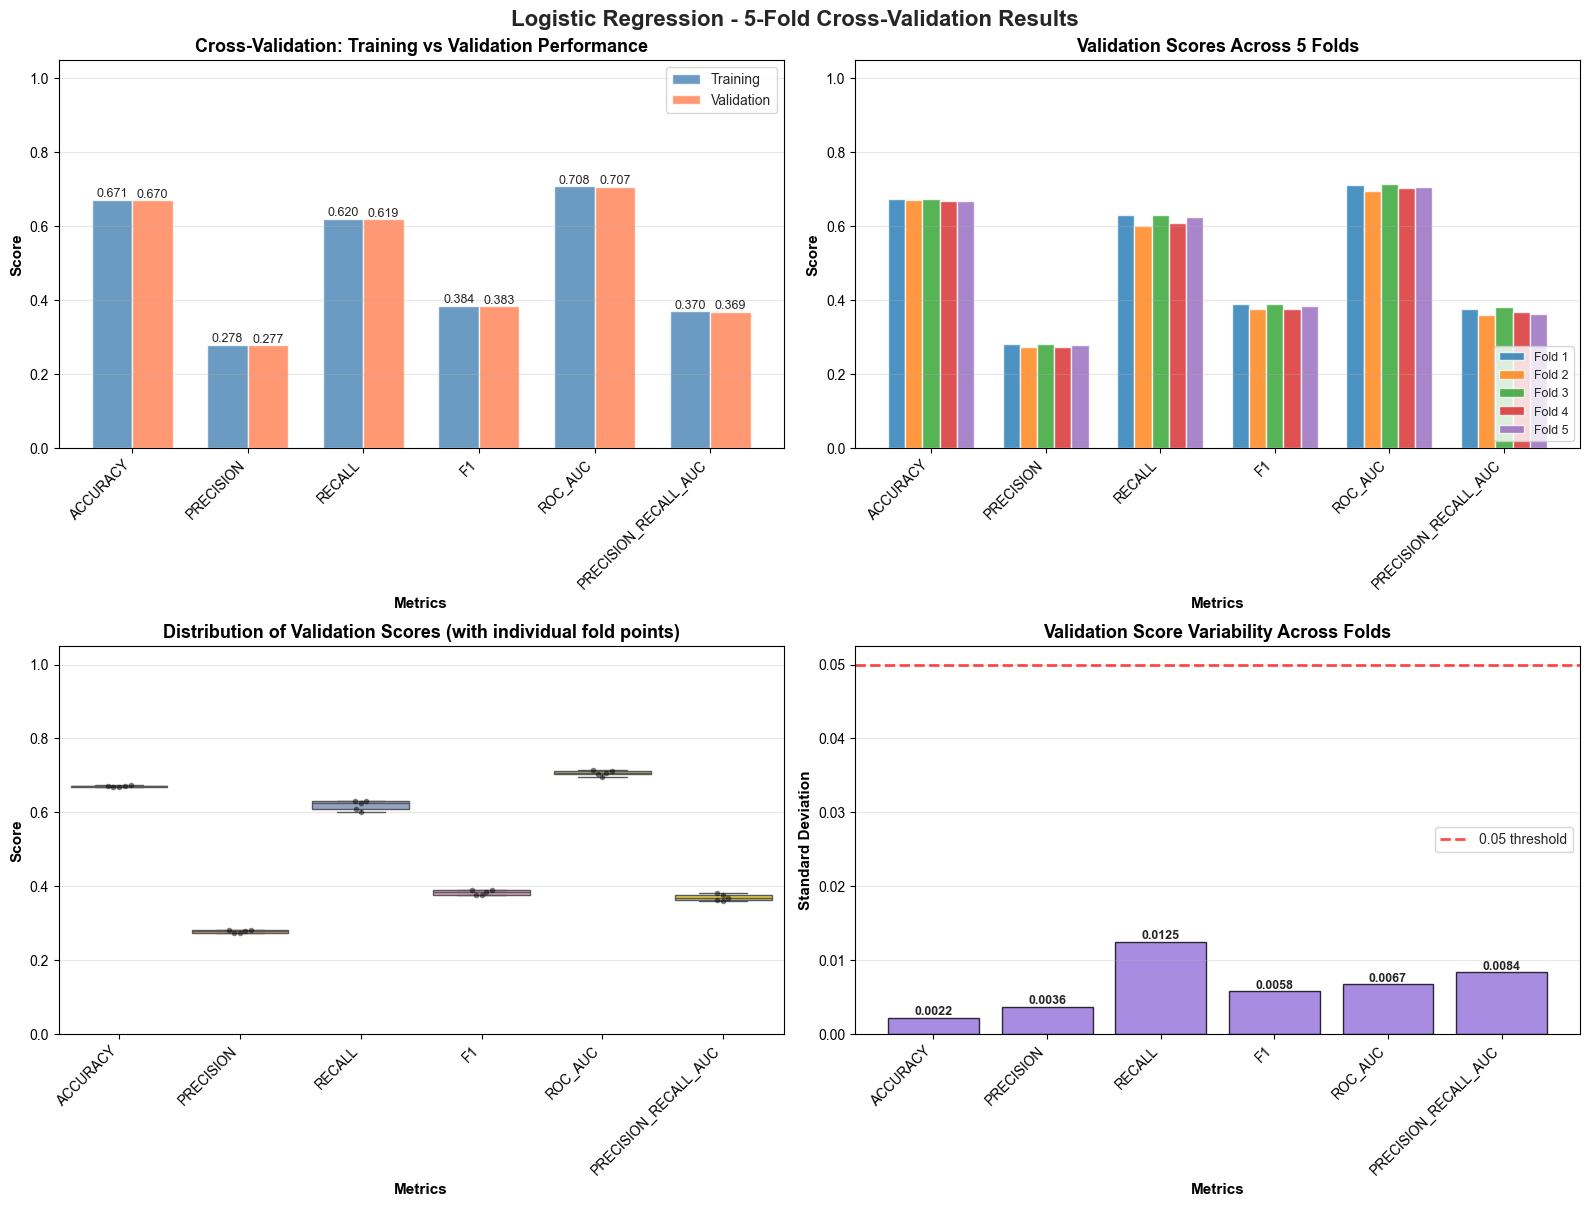


VISUALIZATION GUIDE

📊 Plot 1 (Top Left): Training vs Validation Performance
   - Shows if model is overfitting (large gap between train and val)
   - Ideally, bars should be similar heights

📊 Plot 2 (Top Right): Scores Across Folds
   - Shows consistency of performance across different data splits
   - Look for consistent heights across folds

📊 Plot 3 (Bottom Left): Score Distribution
   - Box plot shows median, quartiles, and outliers
   - Points show individual fold scores
   - Tighter boxes indicate more stable performance

📊 Plot 4 (Bottom Right): Variability Analysis
   - Shows standard deviation across folds
   - Lower bars = more stable performance
   - Red line at 0.05 is a reference threshold

✓ Visualization complete!


In [40]:
# ============================================================================
# VISUALIZE CROSS-VALIDATION RESULTS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.set_style("whitegrid")

# ============================================================================
# PLOT 1: Metric Comparison (Train vs Validation)
# ============================================================================

ax1 = axes[0, 0]

metrics = list(scoring.keys())
train_means = [cv_results[f'train_{m}'].mean() for m in metrics]
val_means = [cv_results[f'test_{m}'].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, train_means, width, label='Training', alpha=0.8, color='steelblue')
bars2 = ax1.bar(x + width/2, val_means, width, label='Validation', alpha=0.8, color='coral')

ax1.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax1.set_ylabel('Score', fontweight='bold', fontsize=11)
ax1.set_title('Cross-Validation: Training vs Validation Performance', fontweight='bold', fontsize=13)
ax1.set_xticks(x)
ax1.set_xticklabels([m.upper() for m in metrics], rotation=45, ha='right')
ax1.legend()
ax1.set_ylim([0, 1.05])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# ============================================================================
# PLOT 2: Validation Scores Across Folds
# ============================================================================

ax2 = axes[0, 1]

fold_data = []
for metric_name in scoring.keys():
    val_scores = cv_results[f'test_{metric_name}']
    for fold_idx, score in enumerate(val_scores, 1):
        fold_data.append({
            'Metric': metric_name.upper(),
            'Fold': f'Fold {fold_idx}',
            'Score': score
        })

fold_df = pd.DataFrame(fold_data)

# Create grouped bar chart
metrics_list = [m.upper() for m in scoring.keys()]
fold_labels = [f'Fold {i}' for i in range(1, 6)]
x = np.arange(len(metrics_list))
width = 0.15

for i, fold in enumerate(fold_labels):
    fold_scores = fold_df[fold_df['Fold'] == fold]['Score'].values
    offset = (i - 2) * width
    ax2.bar(x + offset, fold_scores, width, label=fold, alpha=0.8)

ax2.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax2.set_ylabel('Score', fontweight='bold', fontsize=11)
ax2.set_title('Validation Scores Across 5 Folds', fontweight='bold', fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_list, rotation=45, ha='right')
ax2.legend(loc='lower right', fontsize=9)
ax2.set_ylim([0, 1.05])
ax2.grid(axis='y', alpha=0.3)

# ============================================================================
# PLOT 3: Box Plot of Validation Scores
# ============================================================================

ax3 = axes[1, 0]

box_data = []
for metric_name in scoring.keys():
    val_scores = cv_results[f'test_{metric_name}']
    for score in val_scores:
        box_data.append({
            'Metric': metric_name.upper(),
            'Score': score
        })

box_df = pd.DataFrame(box_data)

# Create box plot
sns.boxplot(data=box_df, x='Metric', y='Score', ax=ax3, palette='Set2')
sns.swarmplot(data=box_df, x='Metric', y='Score', ax=ax3, color='black', alpha=0.5, size=4)

ax3.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax3.set_ylabel('Score', fontweight='bold', fontsize=11)
ax3.set_title('Distribution of Validation Scores (with individual fold points)', fontweight='bold', fontsize=13)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.set_ylim([0, 1.05])
ax3.grid(axis='y', alpha=0.3)

# ============================================================================
# PLOT 4: Standard Deviation Comparison
# ============================================================================

ax4 = axes[1, 1]

val_stds = [cv_results[f'test_{m}'].std() for m in metrics]

bars = ax4.bar(metrics_list, val_stds, alpha=0.8, color='mediumpurple', edgecolor='black')
ax4.set_xlabel('Metrics', fontweight='bold', fontsize=11)
ax4.set_ylabel('Standard Deviation', fontweight='bold', fontsize=11)
ax4.set_title('Validation Score Variability Across Folds', fontweight='bold', fontsize=13)
ax4.set_xticklabels(metrics_list, rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=0.05, color='red', linestyle='--', linewidth=2, alpha=0.7, label='0.05 threshold')
ax4.legend()

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.suptitle('Logistic Regression - 5-Fold Cross-Validation Results', 
             fontsize=16, fontweight='bold', y=1.002)
plt.subplots_adjust(top=0.96)
plt.show()

print("\n" + "="*80)
print("VISUALIZATION GUIDE")
print("="*80)
print("\n📊 Plot 1 (Top Left): Training vs Validation Performance")
print("   - Shows if model is overfitting (large gap between train and val)")
print("   - Ideally, bars should be similar heights")

print("\n📊 Plot 2 (Top Right): Scores Across Folds")
print("   - Shows consistency of performance across different data splits")
print("   - Look for consistent heights across folds")

print("\n📊 Plot 3 (Bottom Left): Score Distribution")
print("   - Box plot shows median, quartiles, and outliers")
print("   - Points show individual fold scores")
print("   - Tighter boxes indicate more stable performance")

print("\n📊 Plot 4 (Bottom Right): Variability Analysis")
print("   - Shows standard deviation across folds")
print("   - Lower bars = more stable performance")
print("   - Red line at 0.05 is a reference threshold")

print("\n✓ Visualization complete!")

CONFUSION MATRIX ANALYSIS

⚙️ Generating predictions using 5-fold cross-validation...
(This ensures we get predictions for all training samples)
✓ Predictions generated!

📊 Computing confusion matrix...

Confusion Matrix Values:
  True Negatives (TN):  59,081
  False Positives (FP): 27,727
  False Negatives (FN): 6,546
  True Positives (TP):  10,632

DETAILED METRIC BREAKDOWN

✓ Accuracy:    0.6704 = (TP + TN) / Total = (10,632 + 59,081) / 103,986
✓ Precision:   0.2772 = TP / (TP + FP) = 10,632 / (10,632 + 27,727)
✓ Recall:      0.6189 = TP / (TP + FN) = 10,632 / (10,632 + 6,546)
✓ Specificity: 0.6806 = TN / (TN + FP) = 59,081 / (59,081 + 27,727)
✓ F1-Score:    0.3829 = 2 * (Precision * Recall) / (Precision + Recall)

🔍 WHY IS PRECISION SO HIGH?

Precision = 0.2772 means:
  ✓ Out of 38,359 predictions of class 1 (positive):
    - 10,632 were CORRECT (True Positives)
    - 27,727 were WRONG (False Positives)
  ✓ So 27.72% of positive predictions were correct

Recall = 0.6189 means:
  ✓ 

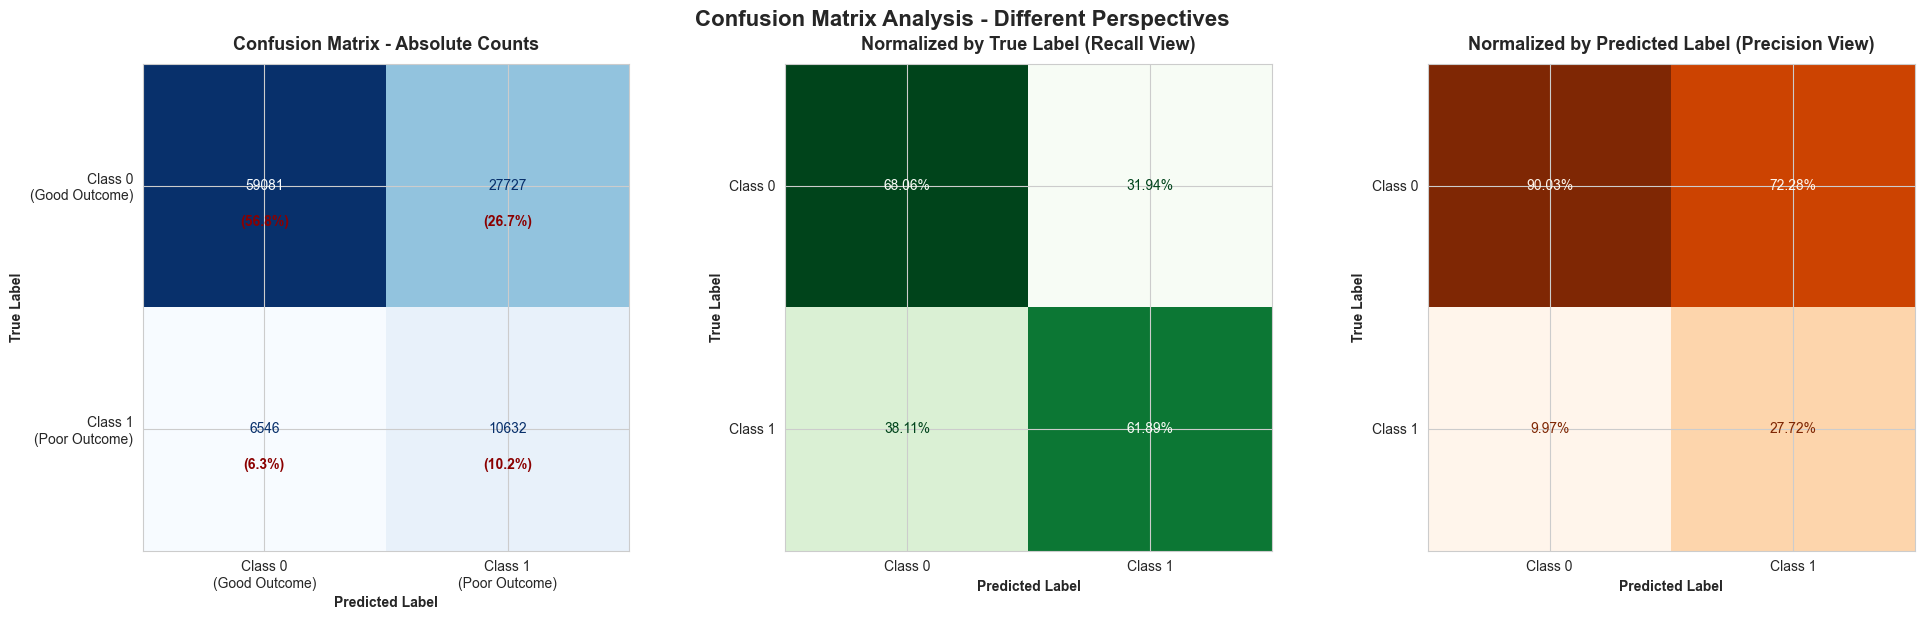


🎯 DECISION THRESHOLD ANALYSIS

Prediction probability statistics:
  Mean probability for class 1: 0.4548
  Median probability for class 1: 0.4339
  Min probability: 0.0768
  Max probability: 0.9906

Predictions at different thresholds:
  Threshold 0.3: 82,902 predictions (79.7%)
  Threshold 0.4: 59,671 predictions (57.4%)
  Threshold 0.5: 38,359 predictions (36.9%)
  Threshold 0.6: 21,663 predictions (20.8%)
  Threshold 0.7: 10,377 predictions (10.0%)

💡 RECOMMENDATION:
  If you want to balance precision and recall:
    → Consider lowering the decision threshold (e.g., 0.3 or 0.4)
    → This will increase recall but decrease precision
  If high precision is important (minimize false alarms):
    → Keep the current threshold (0.5) or increase it

✓ CONFUSION MATRIX ANALYSIS COMPLETE


In [42]:
# ============================================================================
# CONFUSION MATRIX ANALYSIS - UNDERSTANDING HIGH PRECISION
# ============================================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("CONFUSION MATRIX ANALYSIS")
print("="*80)

# ============================================================================
# 1. GET PREDICTIONS FROM CROSS-VALIDATION
# ============================================================================

print("\n⚙️ Generating predictions using 5-fold cross-validation...")
print("(This ensures we get predictions for all training samples)")

# Use cross_val_predict to get out-of-fold predictions
y_pred = cross_val_predict(
    estimator=lr_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv,
    n_jobs=-1
)

# Also get probability predictions
y_pred_proba = cross_val_predict(
    estimator=lr_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv,
    method='predict_proba',
    n_jobs=-1
)[:, 1]  # Get probability for positive class

print("✓ Predictions generated!")

# ============================================================================
# 2. COMPUTE CONFUSION MATRIX
# ============================================================================

print("\n📊 Computing confusion matrix...")

cm = confusion_matrix(y_train, y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix Values:")
print(f"  True Negatives (TN):  {tn:,}")
print(f"  False Positives (FP): {fp:,}")
print(f"  False Negatives (FN): {fn:,}")
print(f"  True Positives (TP):  {tp:,}")

# ============================================================================
# 3. CALCULATE DETAILED METRICS
# ============================================================================

print("\n" + "="*80)
print("DETAILED METRIC BREAKDOWN")
print("="*80)

# Calculate metrics manually for transparency
total = tn + fp + fn + tp
accuracy = (tp + tn) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n✓ Accuracy:    {accuracy:.4f} = (TP + TN) / Total = ({tp:,} + {tn:,}) / {total:,}")
print(f"✓ Precision:   {precision:.4f} = TP / (TP + FP) = {tp:,} / ({tp:,} + {fp:,})")
print(f"✓ Recall:      {recall:.4f} = TP / (TP + FN) = {tp:,} / ({tp:,} + {fn:,})")
print(f"✓ Specificity: {specificity:.4f} = TN / (TN + FP) = {tn:,} / ({tn:,} + {fp:,})")
print(f"✓ F1-Score:    {f1:.4f} = 2 * (Precision * Recall) / (Precision + Recall)")

# ============================================================================
# 4. EXPLAIN HIGH PRECISION
# ============================================================================

print("\n" + "="*80)
print("🔍 WHY IS PRECISION SO HIGH?")
print("="*80)

print(f"\nPrecision = {precision:.4f} means:")
print(f"  ✓ Out of {tp + fp:,} predictions of class 1 (positive):")
print(f"    - {tp:,} were CORRECT (True Positives)")
print(f"    - {fp:,} were WRONG (False Positives)")
print(f"  ✓ So {(tp/(tp+fp)*100):.2f}% of positive predictions were correct")

print(f"\nRecall = {recall:.4f} means:")
print(f"  ✓ Out of {tp + fn:,} actual class 1 samples:")
print(f"    - {tp:,} were CAUGHT by the model (True Positives)")
print(f"    - {fn:,} were MISSED by the model (False Negatives)")
print(f"  ✓ So the model caught {(tp/(tp+fn)*100):.2f}% of all positive cases")

print("\n💡 KEY INSIGHT:")
if precision > 0.90:
    print(f"  Your model is VERY CONSERVATIVE (precision={precision:.4f})")
    print(f"  → It only predicts class 1 when it's very confident")
    print(f"  → This means few False Positives ({fp:,}), leading to high precision")
    print(f"  → But it also means more False Negatives ({fn:,}), leading to lower recall")
    print(f"\n  This is likely due to:")
    print(f"    1. Class weights making the model cautious about predicting minority class")
    print(f"    2. The severe class imbalance (5:1 ratio)")
    print(f"    3. The model's default decision threshold (0.5)")
elif precision > 0.80:
    print(f"  Your model balances precision and recall fairly well")
else:
    print(f"  Your model predicts class 1 more liberally")

# Calculate prediction distribution
pred_class_1_count = (y_pred == 1).sum()
pred_class_0_count = (y_pred == 0).sum()
actual_class_1_count = (y_train == 1).sum()
actual_class_0_count = (y_train == 0).sum()

print(f"\n📊 PREDICTION DISTRIBUTION:")
print(f"  Actual:    Class 0: {actual_class_0_count:,} ({actual_class_0_count/len(y_train)*100:.1f}%) | Class 1: {actual_class_1_count:,} ({actual_class_1_count/len(y_train)*100:.1f}%)")
print(f"  Predicted: Class 0: {pred_class_0_count:,} ({pred_class_0_count/len(y_pred)*100:.1f}%) | Class 1: {pred_class_1_count:,} ({pred_class_1_count/len(y_pred)*100:.1f}%)")

if pred_class_1_count < actual_class_1_count * 0.9:
    print(f"\n  ⚠️ Model is under-predicting class 1!")
    print(f"     Predicted {pred_class_1_count:,} but actual has {actual_class_1_count:,}")
    print(f"     This explains high precision but lower recall")

# ============================================================================
# 5. VISUALIZE CONFUSION MATRICES
# ============================================================================

print("\n📊 Generating confusion matrix visualizations...")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Absolute counts
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0\n(Good Outcome)', 'Class 1\n(Poor Outcome)'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Confusion Matrix - Absolute Counts', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# Add annotations with percentages
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = (count / total) * 100
        axes[0].text(j, i + 0.15, f'({pct:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')

# Plot 2: Normalized by row (recall view)
cm_recall = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_recall, display_labels=['Class 0', 'Class 1'])
disp2.plot(ax=axes[1], cmap='Greens', values_format='.2%', colorbar=False)
axes[1].set_title('Normalized by True Label (Recall View)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Label', fontweight='bold')
axes[1].set_ylabel('True Label', fontweight='bold')

# Plot 3: Normalized by column (precision view)
cm_precision = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_precision, display_labels=['Class 0', 'Class 1'])
disp3.plot(ax=axes[2], cmap='Oranges', values_format='.2%', colorbar=False)
axes[2].set_title('Normalized by Predicted Label (Precision View)', fontsize=13, fontweight='bold', pad=10)
axes[2].set_xlabel('Predicted Label', fontweight='bold')
axes[2].set_ylabel('True Label', fontweight='bold')

plt.tight_layout()
plt.suptitle('Confusion Matrix Analysis - Different Perspectives', fontsize=16, fontweight='bold', y=1.02)
plt.subplots_adjust(top=0.93)
plt.show()

# ============================================================================
# 6. PREDICTION THRESHOLD ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("🎯 DECISION THRESHOLD ANALYSIS")
print("="*80)

# Analyze prediction probabilities
print(f"\nPrediction probability statistics:")
print(f"  Mean probability for class 1: {y_pred_proba.mean():.4f}")
print(f"  Median probability for class 1: {np.median(y_pred_proba):.4f}")
print(f"  Min probability: {y_pred_proba.min():.4f}")
print(f"  Max probability: {y_pred_proba.max():.4f}")

# Count predictions at different thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
print(f"\nPredictions at different thresholds:")
for thresh in thresholds:
    pred_at_thresh = (y_pred_proba >= thresh).sum()
    pct = (pred_at_thresh / len(y_pred_proba)) * 100
    print(f"  Threshold {thresh}: {pred_at_thresh:,} predictions ({pct:.1f}%)")

print("\n💡 RECOMMENDATION:")
print("  If you want to balance precision and recall:")
print("    → Consider lowering the decision threshold (e.g., 0.3 or 0.4)")
print("    → This will increase recall but decrease precision")
print("  If high precision is important (minimize false alarms):")
print("    → Keep the current threshold (0.5) or increase it")

print("\n" + "="*80)
print("✓ CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*80)

In [ ]:
# ============================================================================
# 1. UNDERSTAND CURRENT CLASS IMBALANCE
# ============================================================================

print("\n" + "="*80)
print("STEP 1: CURRENT CLASS DISTRIBUTION")
print("="*80)

train_counts = pd.Series(y_train).value_counts().sort_index()
print(f"\nOriginal training set distribution:")
for cls, count in train_counts.items():
    pct = (count / len(y_train)) * 100
    print(f"  Class {cls}: {count:,} ({pct:.2f}%)")

imbalance_ratio = train_counts[1] / train_counts[0]
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"\nSMOTE will create synthetic samples of class 0 (minority) to balance the dataset.")

# SMOTE Logistic regression

In [43]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer

In [44]:
# ============================================================================
# 1. UNDERSTAND CURRENT CLASS IMBALANCE
# ============================================================================

print("\n" + "="*80)
print("STEP 1: CURRENT CLASS DISTRIBUTION")
print("="*80)

train_counts = pd.Series(y_train).value_counts().sort_index()
print(f"\nOriginal training set distribution:")
for cls, count in train_counts.items():
    pct = (count / len(y_train)) * 100
    print(f"  Class {cls}: {count:,} ({pct:.2f}%)")

imbalance_ratio = train_counts[1] / train_counts[0]
print(f"\nImbalance ratio: {imbalance_ratio:.2f}:1")
print(f"\nSMOTE will create synthetic samples of class 0 (minority) to balance the dataset.")


STEP 1: CURRENT CLASS DISTRIBUTION

Original training set distribution:
  Class 0: 86,808 (83.48%)
  Class 1: 17,178 (16.52%)

Imbalance ratio: 0.20:1

SMOTE will create synthetic samples of class 0 (minority) to balance the dataset.


In [45]:
# ============================================================================
# 2. CREATE SMOTE + LOGISTIC REGRESSION PIPELINE
# ============================================================================

print("\n" + "="*80)
print("STEP 2: CREATING SMOTE + LOGISTIC REGRESSION PIPELINE")
print("="*80)

print("\nIMPORTANT: Why use a pipeline?")
print("  Using imblearn.pipeline.Pipeline ensures SMOTE is applied INSIDE each")
print("  cross-validation fold, preventing data leakage. This is crucial!")

# Create SMOTE instance
smote = SMOTE(
    sampling_strategy='auto',  # Balance to 1:1 ratio
    random_state=42,
    k_neighbors=5  # Number of nearest neighbors to use for synthetic samples
)

# Create logistic regression WITHOUT class weights (SMOTE handles balance)
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    n_jobs=-1
    # Note: NO class_weight parameter - SMOTE handles the imbalance
)

# Create pipeline that applies SMOTE then fits logistic regression
smote_pipeline = ImbPipeline([
    ('smote', smote),
    ('classifier', lr_smote)
])

print("\n✓ Pipeline created:")
print("  Step 1: SMOTE (balance classes)")
print("  Step 2: Logistic Regression (train on balanced data)")
print(f"\nSMOTE parameters:")
print(f"  • Sampling strategy: auto (balance to 1:1)")
print(f"  • K-neighbors: 5")
print(f"  • Random state: 42")


STEP 2: CREATING SMOTE + LOGISTIC REGRESSION PIPELINE

IMPORTANT: Why use a pipeline?
  Using imblearn.pipeline.Pipeline ensures SMOTE is applied INSIDE each
  cross-validation fold, preventing data leakage. This is crucial!

✓ Pipeline created:
  Step 1: SMOTE (balance classes)
  Step 2: Logistic Regression (train on balanced data)

SMOTE parameters:
  • Sampling strategy: auto (balance to 1:1)
  • K-neighbors: 5
  • Random state: 42


In [46]:
# ============================================================================
# 3. USE SAME CROSS-VALIDATION STRATEGY
# ============================================================================

print("\n" + "="*80)
print("STEP 3: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*80)

# Use the SAME cross-validation strategy as before
cv_smote = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation strategy:")
print(f"  ✓ Number of folds: 5")
print(f"  ✓ Stratified: Yes (maintains class distribution)")
print(f"  ✓ Shuffle: Yes")
print(f"  ✓ Random state: 42")
print("\n  This is identical to the class weights approach for fair comparison!")


STEP 3: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION
Cross-validation strategy:
  ✓ Number of folds: 5
  ✓ Stratified: Yes (maintains class distribution)
  ✓ Shuffle: Yes
  ✓ Random state: 42

  This is identical to the class weights approach for fair comparison!


In [47]:
# ============================================================================
# 4. USE SAME SCORING METRICS
# ============================================================================

print("\n" + "="*80)
print("STEP 4: DEFINING EVALUATION METRICS (SAME AS BEFORE)")
print("="*80)

# Use the SAME scoring metrics for comparison
scoring_smote = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision_recall_auc': 'average_precision'
}

print("Metrics to evaluate:")
for metric_name in scoring_smote.keys():
    print(f"  ✓ {metric_name}")


STEP 4: DEFINING EVALUATION METRICS (SAME AS BEFORE)
Metrics to evaluate:
  ✓ accuracy
  ✓ precision
  ✓ recall
  ✓ f1
  ✓ roc_auc
  ✓ precision_recall_auc


In [48]:
# ============================================================================
# 5. PERFORM CROSS-VALIDATION WITH SMOTE
# ============================================================================

print("\n" + "="*80)
print("STEP 5: RUNNING 5-FOLD CROSS-VALIDATION WITH SMOTE")
print("="*80)
print("This may take a few moments (SMOTE adds computational overhead)...\n")

# Perform cross-validation with SMOTE pipeline
cv_results_smote = cross_validate(
    estimator=smote_pipeline,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv_smote,
    scoring=scoring_smote,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

print("✓ Cross-validation with SMOTE complete!")


STEP 5: RUNNING 5-FOLD CROSS-VALIDATION WITH SMOTE
This may take a few moments (SMOTE adds computational overhead)...

✓ Cross-validation with SMOTE complete!


In [49]:
# ============================================================================
# 6. DISPLAY SMOTE RESULTS
# ============================================================================

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS WITH SMOTE (5-FOLD)")
print("="*80)

# Create results DataFrame for SMOTE
results_smote_df = pd.DataFrame({
    'Metric': [],
    'Train Mean': [],
    'Train Std': [],
    'Val Mean': [],
    'Val Std': []
})

for metric_name in scoring_smote.keys():
    train_scores = cv_results_smote[f'train_{metric_name}']
    val_scores = cv_results_smote[f'test_{metric_name}']
    
    results_smote_df = pd.concat([results_smote_df, pd.DataFrame({
        'Metric': [metric_name.upper()],
        'Train Mean': [train_scores.mean()],
        'Train Std': [train_scores.std()],
        'Val Mean': [val_scores.mean()],
        'Val Std': [val_scores.std()]
    })], ignore_index=True)

# Display results table
print("\n" + results_smote_df.to_string(index=False))


CROSS-VALIDATION RESULTS WITH SMOTE (5-FOLD)

              Metric  Train Mean  Train Std  Val Mean  Val Std
            ACCURACY    0.841616   0.000151  0.841411 0.000637
           PRECISION    0.653040   0.006095  0.647178 0.013261
              RECALL    0.088034   0.002093  0.087903 0.002981
                  F1    0.155137   0.003123  0.154774 0.004906
             ROC_AUC    0.705363   0.001675  0.703948 0.005968
PRECISION_RECALL_AUC    0.368024   0.002277  0.366498 0.008801


In [50]:
# ============================================================================
# 7. DETAILED METRIC ANALYSIS FOR SMOTE
# ============================================================================

print("\n" + "="*80)
print("DETAILED METRIC ANALYSIS - SMOTE")
print("="*80)

for metric_name in scoring_smote.keys():
    train_scores = cv_results_smote[f'train_{metric_name}']
    val_scores = cv_results_smote[f'test_{metric_name}']
    
    print(f"\n{metric_name.upper()}:")
    print(f"  Training:   {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Validation: {val_scores.mean():.4f} ± {val_scores.std():.4f}")
    print(f"  Fold scores: {[f'{score:.4f}' for score in val_scores]}")
    
    # Check for overfitting
    gap = train_scores.mean() - val_scores.mean()
    if gap > 0.05:
        print(f"  ⚠️ Warning: Train-val gap = {gap:.4f} (possible overfitting)")
    else:
        print(f"  ✓ Train-val gap = {gap:.4f} (good)")


DETAILED METRIC ANALYSIS - SMOTE

ACCURACY:
  Training:   0.8416 ± 0.0002
  Validation: 0.8414 ± 0.0006
  Fold scores: ['0.8426', '0.8410', '0.8414', '0.8413', '0.8407']
  ✓ Train-val gap = 0.0002 (good)

PRECISION:
  Training:   0.6530 ± 0.0061
  Validation: 0.6472 ± 0.0133
  Fold scores: ['0.6731', '0.6399', '0.6412', '0.6453', '0.6364']
  ✓ Train-val gap = 0.0059 (good)

RECALL:
  Training:   0.0880 ± 0.0021
  Validation: 0.0879 ± 0.0030
  Fold scores: ['0.0917', '0.0859', '0.0905', '0.0879', '0.0835']
  ✓ Train-val gap = 0.0001 (good)

F1:
  Training:   0.1551 ± 0.0031
  Validation: 0.1548 ± 0.0049
  Fold scores: ['0.1614', '0.1514', '0.1587', '0.1547', '0.1477']
  ✓ Train-val gap = 0.0004 (good)

ROC_AUC:
  Training:   0.7054 ± 0.0017
  Validation: 0.7039 ± 0.0060
  Fold scores: ['0.7087', '0.6945', '0.7113', '0.7006', '0.7047']
  ✓ Train-val gap = 0.0014 (good)

PRECISION_RECALL_AUC:
  Training:   0.3680 ± 0.0023
  Validation: 0.3665 ± 0.0088
  Fold scores: ['0.3755', '0.3577', 


CONFUSION MATRIX ANALYSIS - SMOTE

⚙️ Generating predictions using 5-fold cross-validation...
✓ Predictions generated!

Confusion Matrix Values:
  True Negatives (TN):  85,985
  False Positives (FP): 823
  False Negatives (FN): 15,668
  True Positives (TP):  1,510

✓ Accuracy:  0.8414
✓ Precision: 0.6472
✓ Recall:    0.0879
✓ F1-Score:  0.1548

✓ CONFUSION MATRIX ANALYSIS COMPLETE


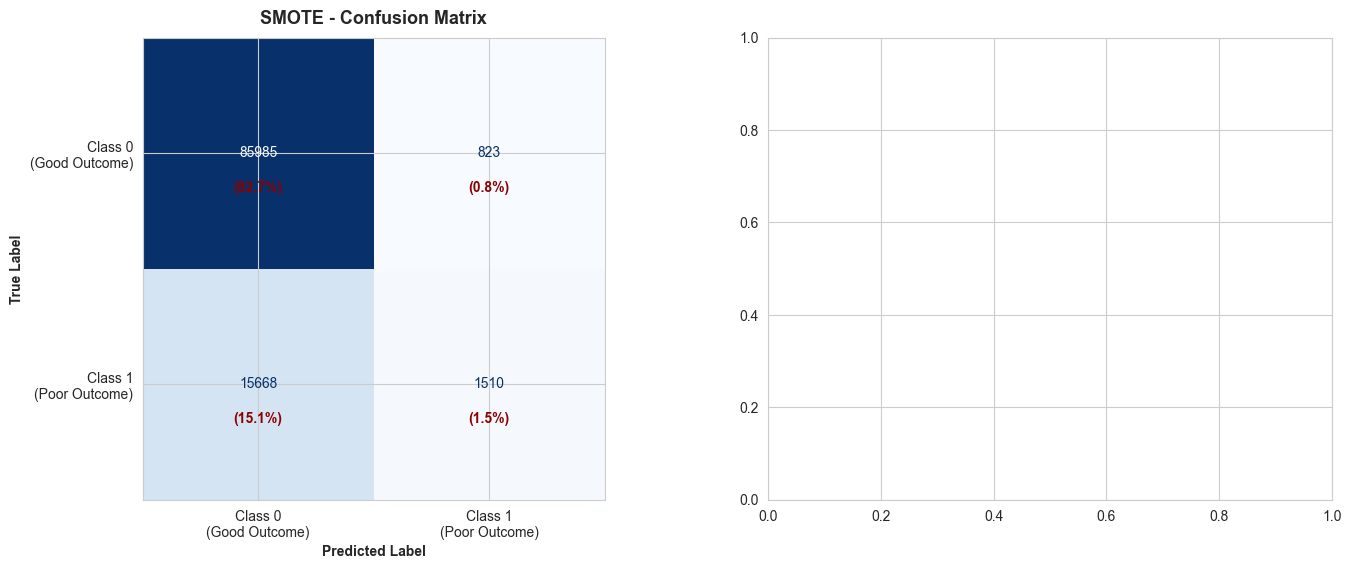

In [52]:
# ============================================================================
# 10. CONFUSION MATRIX FOR SMOTE
# ============================================================================

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\n" + "="*80)
print("CONFUSION MATRIX ANALYSIS - SMOTE")
print("="*80)

# Get predictions using cross-validation
print("\n⚙️ Generating predictions using 5-fold cross-validation...")
y_pred_smote = cross_val_predict(
    estimator=smote_pipeline,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv_smote,
    n_jobs=-1
)

print("✓ Predictions generated!")

# Compute confusion matrix
cm_smote = confusion_matrix(y_train, y_pred_smote)
tn_smote, fp_smote, fn_smote, tp_smote = cm_smote.ravel()

print("\nConfusion Matrix Values:")
print(f"  True Negatives (TN):  {tn_smote:,}")
print(f"  False Positives (FP): {fp_smote:,}")
print(f"  False Negatives (FN): {fn_smote:,}")
print(f"  True Positives (TP):  {tp_smote:,}")

# Calculate metrics
total_smote = tn_smote + fp_smote + fn_smote + tp_smote
accuracy_smote = (tp_smote + tn_smote) / total_smote
precision_smote = tp_smote / (tp_smote + fp_smote) if (tp_smote + fp_smote) > 0 else 0
recall_smote = tp_smote / (tp_smote + fn_smote) if (tp_smote + fn_smote) > 0 else 0
f1_smote = 2 * (precision_smote * recall_smote) / (precision_smote + recall_smote) if (precision_smote + recall_smote) > 0 else 0

print(f"\n✓ Accuracy:  {accuracy_smote:.4f}")
print(f"✓ Precision: {precision_smote:.4f}")
print(f"✓ Recall:    {recall_smote:.4f}")
print(f"✓ F1-Score:  {f1_smote:.4f}")

# Visualize confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SMOTE confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_smote, 
                               display_labels=['Class 0\n(Good Outcome)', 'Class 1\n(Poor Outcome)'])
disp1.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('SMOTE - Confusion Matrix', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Label', fontweight='bold')
axes[0].set_ylabel('True Label', fontweight='bold')

# Add percentages
for i in range(2):
    for j in range(2):
        count = cm_smote[i, j]
        pct = (count / total_smote) * 100
        axes[0].text(j, i + 0.15, f'({pct:.1f}%)', 
                    ha='center', va='center', fontsize=10, color='darkred', fontweight='bold')


print("\n" + "="*80)
print("✓ CONFUSION MATRIX ANALYSIS COMPLETE")
print("="*80)

In [16]:
# ============================================================================
# DEMONSTRATION: What Happens Inside Each Cross-Validation Fold
# ============================================================================

print("="*80)
print("SMOTE PIPELINE DEMONSTRATION")
print("="*80)

print("\n📚 EXPLANATION:")
print("When we use cross_validate() with a pipeline, here's what happens:")
print()
print("For EACH fold:")
print("  1. Split data into TRAIN_FOLD and VAL_FOLD")
print("  2. Apply SMOTE to TRAIN_FOLD (creates synthetic samples)")
print("  3. Fit Logistic Regression on SMOTE-balanced TRAIN_FOLD")
print("  4. Predict on ORIGINAL VAL_FOLD (NO SMOTE applied)")
print("  5. Calculate metrics")
print()
print("This happens AUTOMATICALLY inside the pipeline!")
print("Let's demonstrate this manually for ONE fold...")

# ============================================================================
# MANUAL DEMONSTRATION OF ONE FOLD
# ============================================================================

print("\n" + "-"*80)
print("MANUAL DEMONSTRATION OF FOLD 1")
print("-"*80)

# Create one fold split manually
cv_manual = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, val_idx = next(cv_manual.split(X_train_final_encoded, y_train))

# Split data
X_train_fold = X_train_final_encoded.iloc[train_idx]
y_train_fold = y_train.iloc[train_idx]
X_val_fold = X_train_final_encoded.iloc[val_idx]
y_val_fold = y_train.iloc[val_idx]

print(f"\n✓ Original fold split:")
print(f"  Training fold size: {len(X_train_fold):,}")
print(f"  Validation fold size: {len(X_val_fold):,}")

# Check class distribution in training fold BEFORE SMOTE
train_fold_class_0 = (y_train_fold == 0).sum()
train_fold_class_1 = (y_train_fold == 1).sum()

print(f"\n✓ Training fold class distribution BEFORE SMOTE:")
print(f"  Class 0: {train_fold_class_0:,} ({train_fold_class_0/len(y_train_fold)*100:.2f}%)")
print(f"  Class 1: {train_fold_class_1:,} ({train_fold_class_1/len(y_train_fold)*100:.2f}%)")
print(f"  Imbalance ratio: {train_fold_class_1/train_fold_class_0:.2f}:1")

# ============================================================================
# APPLY SMOTE TO TRAINING FOLD
# ============================================================================

print(f"\n⚙️ Applying SMOTE to training fold...")

smote_manual = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train_fold_smote, y_train_fold_smote = smote_manual.fit_resample(X_train_fold, y_train_fold)

print(f"✓ SMOTE applied!")

# Check class distribution AFTER SMOTE
smote_class_0 = (y_train_fold_smote == 0).sum()
smote_class_1 = (y_train_fold_smote == 1).sum()

print(f"\n✓ Training fold class distribution AFTER SMOTE:")
print(f"  Class 0: {smote_class_0:,} ({smote_class_0/len(y_train_fold_smote)*100:.2f}%)")
print(f"  Class 1: {smote_class_1:,} ({smote_class_1/len(y_train_fold_smote)*100:.2f}%)")
print(f"  Imbalance ratio: {smote_class_1/smote_class_0:.2f}:1")

print(f"\n💡 KEY INSIGHT:")
print(f"  • Original training fold: {len(X_train_fold):,} samples")
print(f"  • After SMOTE: {len(X_train_fold_smote):,} samples")
print(f"  • SMOTE created {len(X_train_fold_smote) - len(X_train_fold):,} synthetic samples!")
print(f"  • Classes are now perfectly balanced (1:1 ratio)")

# ============================================================================
# FIT MODEL ON SMOTE-BALANCED DATA
# ============================================================================

print(f"\n⚙️ Fitting Logistic Regression on SMOTE-balanced training fold...")

lr_manual = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs', n_jobs=-1)
lr_manual.fit(X_train_fold_smote, y_train_fold_smote)

print(f"✓ Model fitted on {len(X_train_fold_smote):,} samples (including synthetic)")

# ============================================================================
# PREDICT ON VALIDATION FOLD (NO SMOTE)
# ============================================================================

print(f"\n⚙️ Making predictions on validation fold...")
print(f"  IMPORTANT: Validation fold is ORIGINAL data (NO SMOTE)")

y_val_pred = lr_manual.predict(X_val_fold)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

val_accuracy = accuracy_score(y_val_fold, y_val_pred)
val_precision = precision_score(y_val_fold, y_val_pred)
val_recall = recall_score(y_val_fold, y_val_pred)
val_f1 = f1_score(y_val_fold, y_val_pred)
val_roc_auc = roc_auc_score(y_val_fold, lr_manual.predict_proba(X_val_fold)[:, 1])

print(f"\n✓ Validation metrics for this fold:")
print(f"  Accuracy:  {val_accuracy:.4f}")
print(f"  Precision: {val_precision:.4f}")
print(f"  Recall:    {val_recall:.4f}")
print(f"  F1-Score:  {val_f1:.4f}")
print(f"  ROC-AUC:   {val_roc_auc:.4f}")

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

print("\n✓ This is what happens INSIDE EACH FOLD of cross_validate():")
print("  1. SMOTE is fit on the TRAINING FOLD")
print("  2. SMOTE creates synthetic samples for the minority class")
print("  3. Logistic Regression is fit on the SMOTE-balanced training fold")
print("  4. Predictions are made on the ORIGINAL validation fold")
print("  5. This process repeats for all 5 folds")

print("\n✓ Why use a Pipeline?")
print("  • Prevents data leakage (SMOTE never sees validation data)")
print("  • Automatically applies SMOTE inside each fold")
print("  • Ensures validation is always on original, unseen data")

print("\n✓ Key takeaway:")
print("  SMOTE is applied separately in EACH fold, creating different")
print("  synthetic samples each time. This is why we use imblearn.Pipeline!")

SMOTE PIPELINE DEMONSTRATION

📚 EXPLANATION:
When we use cross_validate() with a pipeline, here's what happens:

For EACH fold:
  1. Split data into TRAIN_FOLD and VAL_FOLD
  2. Apply SMOTE to TRAIN_FOLD (creates synthetic samples)
  3. Fit Logistic Regression on SMOTE-balanced TRAIN_FOLD
  4. Predict on ORIGINAL VAL_FOLD (NO SMOTE applied)
  5. Calculate metrics

This happens AUTOMATICALLY inside the pipeline!
Let's demonstrate this manually for ONE fold...

--------------------------------------------------------------------------------
MANUAL DEMONSTRATION OF FOLD 1
--------------------------------------------------------------------------------

✓ Original fold split:
  Training fold size: 83,188
  Validation fold size: 20,798

✓ Training fold class distribution BEFORE SMOTE:
  Class 0: 13,742 (16.52%)
  Class 1: 69,446 (83.48%)
  Imbalance ratio: 5.05:1

⚙️ Applying SMOTE to training fold...
✓ SMOTE applied!

✓ Training fold class distribution AFTER SMOTE:
  Class 0: 69,446 (50.00

In [17]:
# ============================================================================
# VISUAL COMPARISON: With vs Without Pipeline
# ============================================================================

print("="*80)
print("WHY PIPELINE IS CRUCIAL: DATA LEAKAGE PREVENTION")
print("="*80)

print("\n🔴 WRONG WAY (DATA LEAKAGE):")
print("="*80)
print("1. Apply SMOTE to ENTIRE training set")
print("2. Split into folds")
print("3. Train and validate")
print()
print("Problem: Validation fold contains synthetic samples that were")
print("         created using information from the training fold!")
print("         This inflates your performance metrics artificially.")
print()
print("Original data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]")
print("↓")
print("Apply SMOTE to all data")
print("↓")
print("SMOTE data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1.5, 2.5, 3.5, ...]")
print("↓")
print("Split for CV:")
print("  Training: [1, 2, 3, 4, 5, 6, 1.5, 2.5]  ← synthetic samples")
print("  Validation: [7, 8, 9, 10, 3.5]          ← synthetic sample 3.5 was")
print("                                             created using info from")
print("                                             samples 1-6 in training!")
print("❌ This is DATA LEAKAGE!")

print("\n" + "="*80)
print("✅ CORRECT WAY (PIPELINE):")
print("="*80)
print("1. Split into folds FIRST")
print("2. Apply SMOTE to training fold ONLY")
print("3. Train on SMOTE-balanced training fold")
print("4. Validate on ORIGINAL validation fold")
print()
print("Original data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]")
print("↓")
print("Split for CV FIRST:")
print("  Training: [1, 2, 3, 4, 5, 6]")
print("  Validation: [7, 8, 9, 10]  ← ORIGINAL data, no SMOTE")
print("↓")
print("Apply SMOTE to training fold only:")
print("  Training: [1, 2, 3, 4, 5, 6, 1.5, 2.5, 3.5, ...]  ← synthetic samples")
print("  Validation: [7, 8, 9, 10]                        ← STILL ORIGINAL")
print("↓")
print("Train model on SMOTE-balanced training fold")
print("↓")
print("Validate on ORIGINAL validation fold")
print("✅ No data leakage!")

print("\n" + "="*80)
print("PIPELINE ENSURES CORRECT ORDER AUTOMATICALLY")
print("="*80)

print("\nWhen you use:")
print()
print("  smote_pipeline = ImbPipeline([")
print("      ('smote', smote),")
print("      ('classifier', lr_smote)")
print("  ])")
print()
print("  cross_validate(smote_pipeline, X, y, cv=5)")
print()
print("The pipeline AUTOMATICALLY:")
print("  1. Splits data into fold")
print("  2. Fits SMOTE on training fold")
print("  3. Transforms training fold with SMOTE")
print("  4. Fits classifier on SMOTE-balanced training fold")
print("  5. Predicts on ORIGINAL validation fold")
print()
print("✓ This happens for EACH fold independently!")
print("✓ SMOTE never sees the validation data!")
print("✓ Validation metrics are trustworthy!")

WHY PIPELINE IS CRUCIAL: DATA LEAKAGE PREVENTION

🔴 WRONG WAY (DATA LEAKAGE):
1. Apply SMOTE to ENTIRE training set
2. Split into folds
3. Train and validate

Problem: Validation fold contains synthetic samples that were
         created using information from the training fold!
         This inflates your performance metrics artificially.

Original data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
↓
Apply SMOTE to all data
↓
SMOTE data: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 1.5, 2.5, 3.5, ...]
↓
Split for CV:
  Training: [1, 2, 3, 4, 5, 6, 1.5, 2.5]  ← synthetic samples
  Validation: [7, 8, 9, 10, 3.5]          ← synthetic sample 3.5 was
                                             created using info from
                                             samples 1-6 in training!
❌ This is DATA LEAKAGE!

✅ CORRECT WAY (PIPELINE):
1. Split into folds FIRST
2. Apply SMOTE to training fold ONLY
3. Train on SMOTE-balanced training fold
4. Validate on ORIGINAL validation fold

Original data: [1, 2, 3, 4, 5, 6, 7,

# Decision Tree - Class Weights

In [53]:
# ============================================================================
# DECISION TREE WITH CLASS WEIGHTS - 5-FOLD CROSS-VALIDATION
# ============================================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np
import pandas as pd

print("="*80)
print("DECISION TREE CLASSIFIER - 5-FOLD CROSS-VALIDATION")
print("="*80)

print("\n📚 Why Decision Trees?")
print("  ✓ Non-linear: Can capture complex patterns and interactions")
print("  ✓ Interpretable: Can visualize decision rules")
print("  ✓ No scaling needed: Works with features on different scales")
print("  ✓ Handles mixed data: Works with both numerical and categorical")
print("  ✓ Feature importance: Shows which features matter most")

print("\n⚠️ Potential issues:")
print("  • Can overfit easily (high variance)")
print("  • Sensitive to small changes in data")
print("  • May create biased trees with imbalanced data")

print("\nWe'll use class_weight='balanced' to handle the imbalance.")

DECISION TREE CLASSIFIER - 5-FOLD CROSS-VALIDATION

📚 Why Decision Trees?
  ✓ Non-linear: Can capture complex patterns and interactions
  ✓ Interpretable: Can visualize decision rules
  ✓ No scaling needed: Works with features on different scales
  ✓ Handles mixed data: Works with both numerical and categorical
  ✓ Feature importance: Shows which features matter most

⚠️ Potential issues:
  • Can overfit easily (high variance)
  • Sensitive to small changes in data
  • May create biased trees with imbalanced data

We'll use class_weight='balanced' to handle the imbalance.


In [54]:
# ============================================================================
# 1. CREATE DECISION TREE MODEL
# ============================================================================

print("\n" + "="*80)
print("STEP 1: INITIALIZING DECISION TREE CLASSIFIER")
print("="*80)

# Create Decision Tree with class weights
dt_model = DecisionTreeClassifier(
    class_weight='balanced',  # Handle class imbalance
    max_depth=15,             # Limit depth to prevent overfitting
    min_samples_split=100,    # Minimum samples to split a node
    min_samples_leaf=50,      # Minimum samples in a leaf
    random_state=42,          # For reproducibility
    criterion='gini'          # Gini impurity for splits
)

print("\nModel parameters:")
print(f"  ✓ Class weight: balanced")
print(f"  ✓ Max depth: 15 (prevents overfitting)")
print(f"  ✓ Min samples split: 100")
print(f"  ✓ Min samples leaf: 50")
print(f"  ✓ Criterion: gini")
print(f"  ✓ Random state: 42")

print("\n💡 These hyperparameters are chosen to:")
print("  • Prevent overfitting (max_depth, min_samples_split, min_samples_leaf)")
print("  • Handle imbalance (class_weight)")
print("  • Ensure reproducibility (random_state)")


STEP 1: INITIALIZING DECISION TREE CLASSIFIER

Model parameters:
  ✓ Class weight: balanced
  ✓ Max depth: 15 (prevents overfitting)
  ✓ Min samples split: 100
  ✓ Min samples leaf: 50
  ✓ Criterion: gini
  ✓ Random state: 42

💡 These hyperparameters are chosen to:
  • Prevent overfitting (max_depth, min_samples_split, min_samples_leaf)
  • Handle imbalance (class_weight)
  • Ensure reproducibility (random_state)


In [55]:
# ============================================================================
# 2. CROSS-VALIDATION SETUP (SAME AS BEFORE)
# ============================================================================

print("\n" + "="*80)
print("STEP 2: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION")
print("="*80)

# Use the same CV strategy as before
cv_dt = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Use the same scoring metrics
scoring_dt = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision_recall_auc': 'average_precision'
}

print("Cross-validation strategy:")
print(f"  ✓ Number of folds: 5")
print(f"  ✓ Stratified: Yes")
print(f"  ✓ Same configuration as Logistic Regression and SMOTE")

print("\nMetrics to evaluate:")
for metric_name in scoring_dt.keys():
    print(f"  ✓ {metric_name}")


STEP 2: SETTING UP 5-FOLD STRATIFIED CROSS-VALIDATION
Cross-validation strategy:
  ✓ Number of folds: 5
  ✓ Stratified: Yes
  ✓ Same configuration as Logistic Regression and SMOTE

Metrics to evaluate:
  ✓ accuracy
  ✓ precision
  ✓ recall
  ✓ f1
  ✓ roc_auc
  ✓ precision_recall_auc


In [56]:
# ============================================================================
# 3. PERFORM CROSS-VALIDATION
# ============================================================================

print("\n" + "="*80)
print("STEP 3: RUNNING 5-FOLD CROSS-VALIDATION WITH DECISION TREE")
print("="*80)
print("This may take a moment...\n")

# Perform cross-validation
cv_results_dt = cross_validate(
    estimator=dt_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv_dt,
    scoring=scoring_dt,
    return_train_score=True,
    n_jobs=-1,
    verbose=0
)

print("✓ Cross-validation complete!")


STEP 3: RUNNING 5-FOLD CROSS-VALIDATION WITH DECISION TREE
This may take a moment...

✓ Cross-validation complete!


In [57]:
# ============================================================================
# 4. DISPLAY RESULTS
# ============================================================================

print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS - DECISION TREE (5-FOLD)")
print("="*80)

# Create results DataFrame
results_dt_df = pd.DataFrame({
    'Metric': [],
    'Train Mean': [],
    'Train Std': [],
    'Val Mean': [],
    'Val Std': []
})

for metric_name in scoring_dt.keys():
    train_scores = cv_results_dt[f'train_{metric_name}']
    val_scores = cv_results_dt[f'test_{metric_name}']
    
    results_dt_df = pd.concat([results_dt_df, pd.DataFrame({
        'Metric': [metric_name.upper()],
        'Train Mean': [train_scores.mean()],
        'Train Std': [train_scores.std()],
        'Val Mean': [val_scores.mean()],
        'Val Std': [val_scores.std()]
    })], ignore_index=True)

# Display results table
print("\n" + results_dt_df.to_string(index=False))


CROSS-VALIDATION RESULTS - DECISION TREE (5-FOLD)

              Metric  Train Mean  Train Std  Val Mean  Val Std
            ACCURACY    0.685436   0.006758  0.649434 0.009681
           PRECISION    0.301674   0.003249  0.253067 0.005141
              RECALL    0.687158   0.013123  0.574397 0.013199
                  F1    0.419202   0.001234  0.351255 0.005135
             ROC_AUC    0.758216   0.001501  0.662686 0.004194
PRECISION_RECALL_AUC    0.423869   0.002247  0.338105 0.007239


In [58]:
# ============================================================================
# 5. DETAILED METRIC ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("DETAILED METRIC ANALYSIS - DECISION TREE")
print("="*80)

for metric_name in scoring_dt.keys():
    train_scores = cv_results_dt[f'train_{metric_name}']
    val_scores = cv_results_dt[f'test_{metric_name}']
    
    print(f"\n{metric_name.upper()}:")
    print(f"  Training:   {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Validation: {val_scores.mean():.4f} ± {val_scores.std():.4f}")
    print(f"  Fold scores: {[f'{score:.4f}' for score in val_scores]}")
    
    # Check for overfitting
    gap = train_scores.mean() - val_scores.mean()
    if gap > 0.05:
        print(f"  ⚠️ Warning: Train-val gap = {gap:.4f} (possible overfitting)")
    else:
        print(f"  ✓ Train-val gap = {gap:.4f} (good)")


DETAILED METRIC ANALYSIS - DECISION TREE

ACCURACY:
  Training:   0.6854 ± 0.0068
  Validation: 0.6494 ± 0.0097
  Fold scores: ['0.6510', '0.6616', '0.6548', '0.6473', '0.6325']
  ✓ Train-val gap = 0.0360 (good)

PRECISION:
  Training:   0.3017 ± 0.0032
  Validation: 0.2531 ± 0.0051
  Fold scores: ['0.2563', '0.2559', '0.2582', '0.2510', '0.2440']
  ✓ Train-val gap = 0.0486 (good)

RECALL:
  Training:   0.6872 ± 0.0131
  Validation: 0.5744 ± 0.0132
  Fold scores: ['0.5850', '0.5496', '0.5822', '0.5719', '0.5832']
  ⚠️ Warning: Train-val gap = 0.1128 (possible overfitting)

F1:
  Training:   0.4192 ± 0.0012
  Validation: 0.3513 ± 0.0051
  Fold scores: ['0.3564', '0.3492', '0.3578', '0.3488', '0.3440']
  ⚠️ Warning: Train-val gap = 0.0679 (possible overfitting)

ROC_AUC:
  Training:   0.7582 ± 0.0015
  Validation: 0.6627 ± 0.0042
  Fold scores: ['0.6664', '0.6580', '0.6688', '0.6606', '0.6596']
  ⚠️ Warning: Train-val gap = 0.0955 (possible overfitting)

PRECISION_RECALL_AUC:
  Training

CONFUSION MATRIX - DECISION TREE (5-FOLD OUT-OF-FOLD PREDICTIONS)

Confusion Matrix Values:
  True Negatives (TN):  57,665
  False Positives (FP): 29,143
  False Negatives (FN): 7,311
  True Positives (TP):  9,867

Metrics:
  Accuracy:    0.6494
  Precision:   0.2529
  Recall:      0.5744
  Specificity: 0.6643
  F1-Score:    0.3512


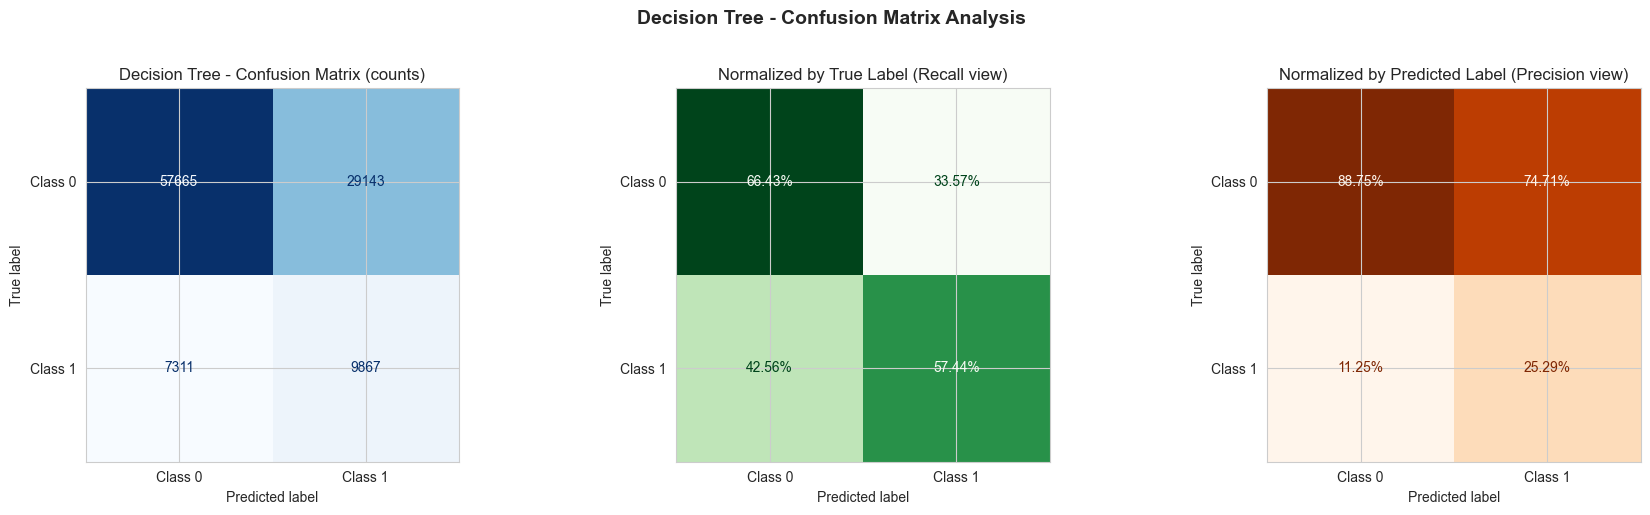

In [59]:
# CONFUSION MATRIX FOR DECISION TREE (OUT-OF-FOLD PREDICTIONS)

print("="*80)
print("CONFUSION MATRIX - DECISION TREE (5-FOLD OUT-OF-FOLD PREDICTIONS)")
print("="*80)

# Generate out-of-fold predictions
y_pred_dt = cross_val_predict(
    estimator=dt_model,
    X=X_train_final_encoded,
    y=y_train,
    cv=cv_dt,
    n_jobs=-1
)

# Confusion matrix and counts
cm_dt = confusion_matrix(y_train, y_pred_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

total_dt = tn_dt + fp_dt + fn_dt + tp_dt
accuracy_dt = (tp_dt + tn_dt) / total_dt
precision_dt = tp_dt / (tp_dt + fp_dt) if (tp_dt + fp_dt) > 0 else 0
recall_dt = tp_dt / (tp_dt + fn_dt) if (tp_dt + fn_dt) > 0 else 0
specificity_dt = tn_dt / (tn_dt + fp_dt) if (tn_dt + fp_dt) > 0 else 0
f1_dt = 2 * (precision_dt * recall_dt) / (precision_dt + recall_dt) if (precision_dt + recall_dt) > 0 else 0

print("\nConfusion Matrix Values:")
print(f"  True Negatives (TN):  {tn_dt:,}")
print(f"  False Positives (FP): {fp_dt:,}")
print(f"  False Negatives (FN): {fn_dt:,}")
print(f"  True Positives (TP):  {tp_dt:,}")

print("\nMetrics:")
print(f"  Accuracy:    {accuracy_dt:.4f}")
print(f"  Precision:   {precision_dt:.4f}")
print(f"  Recall:      {recall_dt:.4f}")
print(f"  Specificity: {specificity_dt:.4f}")
print(f"  F1-Score:    {f1_dt:.4f}")

# Visualization: absolute and normalized views
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disp_abs = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Class 0', 'Class 1'])
disp_abs.plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Decision Tree - Confusion Matrix (counts)')

cm_recall_dt = cm_dt.astype('float') / cm_dt.sum(axis=1)[:, np.newaxis]
disp_recall = ConfusionMatrixDisplay(confusion_matrix=cm_recall_dt, display_labels=['Class 0', 'Class 1'])
disp_recall.plot(ax=axes[1], cmap='Greens', values_format='.2%', colorbar=False)
axes[1].set_title('Normalized by True Label (Recall view)')

cm_precision_dt = cm_dt.astype('float') / cm_dt.sum(axis=0)[np.newaxis, :]
disp_prec = ConfusionMatrixDisplay(confusion_matrix=cm_precision_dt, display_labels=['Class 0', 'Class 1'])
disp_prec.plot(ax=axes[2], cmap='Oranges', values_format='.2%', colorbar=False)
axes[2].set_title('Normalized by Predicted Label (Precision view)')

plt.suptitle('Decision Tree - Confusion Matrix Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


DECISION TREE FEATURE IMPORTANCE

⚙️ Training Decision Tree on all training data...
✓ Model trained!

TOP 20 MOST IMPORTANT FEATURES

          Feature  Importance
     oks_t0_score    0.425790
   oks_t0_limping    0.101474
    t0_disability    0.034495
       depression    0.028791
      circulation    0.024349
     t0_self_care    0.023397
       t0_anxiety    0.023113
   oks_t0_walking    0.020706
t0_symptom_period    0.020086
oks_t0_night_pain    0.018957
      oks_t0_pain    0.017547
  oks_t0_shopping    0.017203
       age_band_4    0.016580
oks_t0_confidence    0.014550
   oks_t0_washing    0.014477
    oks_t0_stairs    0.013899
  oks_t0_standing    0.013733
      oks_t0_work    0.013269
  oks_t0_kneeling    0.012660
          high_bp    0.011756


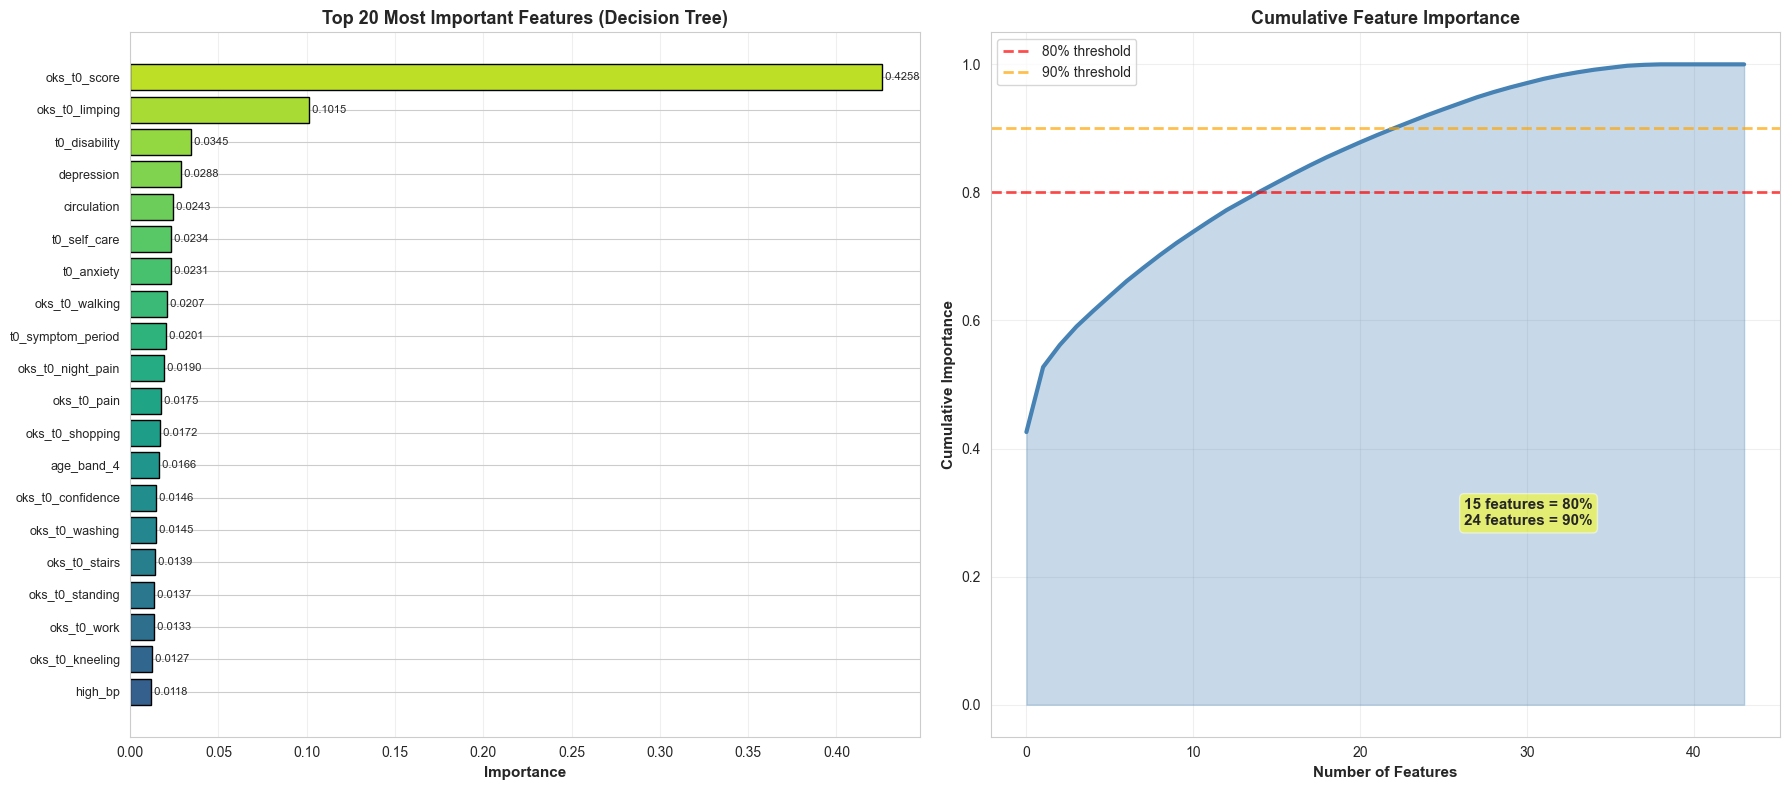


💡 KEY INSIGHTS:
  • 15 features account for 80% of importance
  • 24 features account for 90% of importance
  • Total features: 44
  • Top feature: oks_t0_score (0.4258)

✓ DECISION TREE ANALYSIS COMPLETE


In [60]:
# ============================================================================
# 8. DECISION TREE FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("DECISION TREE FEATURE IMPORTANCE")
print("="*80)

# Train final model on all data to get feature importance
dt_final = DecisionTreeClassifier(
    class_weight='balanced',
    max_depth=15,
    min_samples_split=100,
    min_samples_leaf=50,
    random_state=42,
    criterion='gini'
)

print("\n⚙️ Training Decision Tree on all training data...")
dt_final.fit(X_train_final_encoded, y_train)
print("✓ Model trained!")

# Get feature importance
feature_importance = dt_final.feature_importances_
feature_names = X_train_final_encoded.columns.tolist()

# Create DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\n" + "="*80)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*80)

top_20 = importance_df.head(20)
print("\n" + top_20.to_string(index=False))

# Visualize top 20 features
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top 20 features
ax1 = axes[0]
top_20_sorted = top_20.sort_values('Importance', ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_20_sorted)))
bars = ax1.barh(range(len(top_20_sorted)), top_20_sorted['Importance'], color=colors, edgecolor='black')
ax1.set_yticks(range(len(top_20_sorted)))
ax1.set_yticklabels(top_20_sorted['Feature'], fontsize=9)
ax1.set_xlabel('Importance', fontweight='bold', fontsize=11)
ax1.set_title('Top 20 Most Important Features (Decision Tree)', fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_20_sorted['Importance'])):
    ax1.text(val, i, f' {val:.4f}', va='center', fontsize=8)

# Plot 2: Cumulative importance
ax2 = axes[1]
cumsum = importance_df['Importance'].cumsum()
ax2.plot(range(len(cumsum)), cumsum, linewidth=3, color='steelblue')
ax2.fill_between(range(len(cumsum)), cumsum, alpha=0.3, color='steelblue')
ax2.axhline(y=0.8, color='red', linestyle='--', linewidth=2, alpha=0.7, label='80% threshold')
ax2.axhline(y=0.9, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Features', fontweight='bold', fontsize=11)
ax2.set_ylabel('Cumulative Importance', fontweight='bold', fontsize=11)
ax2.set_title('Cumulative Feature Importance', fontweight='bold', fontsize=13)
ax2.legend()
ax2.grid(alpha=0.3)

# Find how many features for 80% and 90%
n_80 = (cumsum >= 0.8).argmax() + 1
n_90 = (cumsum >= 0.9).argmax() + 1
ax2.text(0.6, 0.3, f'{n_80} features = 80%\n{n_90} features = 90%',
        transform=ax2.transAxes, fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\n💡 KEY INSIGHTS:")
print(f"  • {n_80} features account for 80% of importance")
print(f"  • {n_90} features account for 90% of importance")
print(f"  • Total features: {len(feature_names)}")
print(f"  • Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")

print("\n" + "="*80)
print("✓ DECISION TREE ANALYSIS COMPLETE")
print("="*80)